In [18]:
from astropy.io import ascii

import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack, hstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18


mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches

# from consolidate_photometry import get_fastspec_fit_catalog_V2


%load_ext autoreload
%autoreload 2

    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from fastspec_funcs import get_fastspecfit_path, measure_photo_batch

In [3]:
# get_fastspec_fit_catalog_V2()

In [4]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main_all =  Table.read(filename, hdu="MAIN")
fastspec_all =  Table.read(filename, hdu="FASTSPEC")


In [11]:
fib_based_all =  Table.read(filename, hdu="FIBER_BASED")


In [5]:
print(len(main_all), len(fastspec_all))

445469 445469


In [7]:
spectra_h5_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5"

with h5py.File(spectra_h5_path, "r") as f:
    h5_wave = f["WAVE"][:]
    h5_flux = f["FLUX"][:]
    h5_flux_ivar = f["FLUX_IVAR"][:]
    h5_targetid = f["TARGETID"][:]

## Check fastspec model continuum photo

I have two ways to correct for the nebular emission. 

i) I take the observed spectra and the best fit emission line template. And then subtract the best fit emission line template from the observed spectra, and then measure the photometry on the real data: before and after emission model subtraction. The error will be from the error on the observed spectra continuum!!

ii) Just work on the fastspecfit best fit model, however, it is hard to get a sense for uncertainty in the stellar mass continuum fit ... 


We will test to see how diffferent the corrections from these two methods are!!

In [8]:
len(main)

410604

In [123]:
## maybe let us select the subset where HALPHA_EW is well detected and BGS BRIGHT?
main_i = main[ (main["DELTACHI2"] > 100) & (main["SAMPLE"] == "BGS_BRIGHT") & (fastspec["SNR_R"] > 5) & (fastspec["SNR_Z"] > 5) & (fastspec["SNR_B"] > 5) ]

main_elg = main[ (main["DELTACHI2"] > 40) & (main["SAMPLE"] == "ELG") ]

print(len(main_i))
print(len(main_elg))


5036
148288


In [133]:
# snr_mask = (fastspec["SNR_R"] > 1) | (fastspec["SNR_Z"] > 1) | (fastspec["SNR_B"] > 1)

# main_elg_faint = main[ (main["SAMPLE"] == "ELG") & snr_mask  ]


In [134]:
print(len(main_elg_faint))

24663


24663


148288


In [72]:
def compute_photometry_catalog_COMPARE(catalog,
                               spectra_h5_path,
                               base_dir="/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/healpix",
                               batch_size=500,
                               ncore=8,
                               verbose=True):
    """
    Loop over all objects in a DESI catalog, extract fastspecfit emission-line
    models, match to observed spectra from HDF5, and measure DECam g/r
    photometry for four flux variants:

        1. obs_w_emi     : observed spectra (as-is), DECam + SDSS
        2. obs_no_emi    : observed spectra minus model emission lines
        3. model_w_emi   : model continuum + model emission
        4. model_no_emi  : model continuum only

    Parameters
    ----------
    catalog : astropy Table or structured array
        Must contain columns: TARGETID, HEALPIX, SURVEY, PROGRAM, Z.
    spectra_h5_path : str
        Path to the HDF5 file with WAVE, FLUX, TARGETID datasets.
    base_dir : str
        Root directory of the fastspecfit healpix VAC.
    batch_size : int
        Number of spectra per batch for speclite.
    ncore : int
        Number of parallel workers (reserved for future use; currently serial).
    verbose : bool
        Print progress updates.

    Returns
    -------
    result : astropy Table
    """

    n_objects = len(catalog)
    targetids = np.array(catalog["TARGETID"])

    # ---- Load observed spectra ----
    if verbose:
        print(f"Loading observed spectra from {spectra_h5_path} ...")
    with h5py.File(spectra_h5_path, "r") as f:
        h5_wave = f["WAVE"][:]
        h5_flux = f["FLUX"][:]
        h5_flux_ivar = f["FLUX_IVAR"][:]
        h5_targetid = f["TARGETID"][:]
    h5_tgid_to_row = {t: i for i, t in enumerate(h5_targetid)}
    if verbose:
        print(f"  Loaded {len(h5_targetid)} spectra, wave shape {h5_wave.shape}")

    # ---- Output arrays ----
    g_obs_w_emi      = np.full(n_objects, np.nan)
    r_obs_w_emi      = np.full(n_objects, np.nan)
    
    g_obs_no_emi = np.full(n_objects, np.nan)
    r_obs_no_emi = np.full(n_objects, np.nan)

    g_obs_no_emi_err = np.full(n_objects, np.nan)
    r_obs_no_emi_err = np.full(n_objects, np.nan)

    g_model_w_emi = np.full(n_objects, np.nan)
    r_model_w_emi = np.full(n_objects, np.nan)

    g_model_no_emi = np.full(n_objects, np.nan)
    r_model_no_emi = np.full(n_objects, np.nan)

    halpha_ew      = np.full(n_objects, np.nan)
    halpha_ew_ivar = np.full(n_objects, np.nan)
    snr_r = np.full(n_objects, np.nan)
    snr_b = np.full(n_objects, np.nan)
    snr_z = np.full(n_objects, np.nan)

    # ---- Group by unique FITS file ----
    paths = np.array([
        get_fastspecfit_path(catalog["SURVEY"][i], catalog["PROGRAM"][i],
                            catalog["HEALPIX"][i], base_dir)
        for i in range(n_objects)
    ])
    unique_paths = np.unique(paths)
    n_files = len(unique_paths)

    if verbose:
        print(f"Total objects: {n_objects}, unique FITS files: {n_files}")

    # ---- Main loop over FITS files ----
    for file_idx, upath in enumerate(unique_paths):
        cat_indices = np.where(paths == upath)[0]

        try:
            iron_vac = fits.open(upath, memmap=True)
        except Exception as e:
            if verbose:
                print(f"  SKIP file {upath}: {e}")
            continue

        try:
            model_data = iron_vac["MODELS"].data
            fastspec_data = iron_vac["FASTSPEC"].data
            tgids_file = fastspec_data["TARGETID"]
            tgid_to_fits_row = {t: i for i, t in enumerate(tgids_file)}

            # --- Match catalog rows to FITS rows and HDF5 rows ---
            valid_cat = []
            valid_fits_rows = []
            valid_h5_rows = []
            for ci in cat_indices:
                fits_row = tgid_to_fits_row.get(targetids[ci])
                h5_row = h5_tgid_to_row.get(targetids[ci], -1)
                if fits_row is not None and h5_row >= 0:
                    valid_cat.append(ci)
                    valid_fits_rows.append(fits_row)
                    valid_h5_rows.append(h5_row)
                elif verbose:
                    if fits_row is None:
                        print(f"  WARNING: TARGETID {targetids[ci]} not in FITS {upath}")
                    else:
                        print(f"  WARNING: TARGETID {targetids[ci]} not in HDF5")

            if len(valid_cat) == 0:
                continue

            valid_cat = np.array(valid_cat)
            valid_fits_rows = np.array(valid_fits_rows)
            valid_h5_rows = np.array(valid_h5_rows)

            # --- Extract metadata ---
            halpha_ew[valid_cat]      = fastspec_data["HALPHA_EW"][valid_fits_rows]
            halpha_ew_ivar[valid_cat] = fastspec_data["HALPHA_EW_IVAR"][valid_fits_rows]

            try:
                snr_r[valid_cat] = fastspec_data["SNR_R"][valid_fits_rows]
                snr_b[valid_cat] = fastspec_data["SNR_B"][valid_fits_rows]
                snr_z[valid_cat] = fastspec_data["SNR_Z"][valid_fits_rows]
            except (KeyError, TypeError):
                pass

            # --- Extract model components and observed spectra ---
            continuum = model_data[valid_fits_rows, 0, :]
            smooth_continuum = model_data[valid_fits_rows, 1, :]
            emission  = model_data[valid_fits_rows, 2, :]
            obs_flux  = h5_flux[valid_h5_rows]
            obs_flux_ivar = h5_flux_ivar[valid_h5_rows]

            # === Variant 1: observed spectra, DECam + SDSS ===
            for start in range(0, len(valid_cat), batch_size):
                end = min(start + batch_size, len(valid_cat))
                try:
                    phot = measure_photo_batch(h5_wave, obs_flux[start:end] )
                    g_obs_w_emi[valid_cat[start:end]]      = phot['g_decam']
                    r_obs_w_emi[valid_cat[start:end]]      = phot['r_decam']
                except Exception as e:
                    if verbose:
                        print(f"  Photometry error (obs_w_emi, batch {start}-{end}): {e}")

            # === Variant 2: observed minus emission model ===
            #here we will also compute the error in the continuum photometry!
            obs_minus_emi = obs_flux - emission
            
            for start in range(0, len(valid_cat), batch_size):
                end = min(start + batch_size, len(valid_cat))
                try:
                    phot = measure_photo_batch(h5_wave, obs_minus_emi[start:end], ivar_2d=obs_flux_ivar[start:end])
                    g_obs_no_emi[valid_cat[start:end]] = phot['g_decam']
                    r_obs_no_emi[valid_cat[start:end]] = phot['r_decam']

                    g_obs_no_emi_err[valid_cat[start:end]] = phot['g_decam_err']
                    r_obs_no_emi_err[valid_cat[start:end]] = phot['r_decam_err']
                    
                except Exception as e:
                    if verbose:
                        print(f"  Photometry error (obs_no_emi, batch {start}-{end}): {e}")

            # === Variant 3: model continuum + emission ===
            flux_model_w_emi = continuum + emission + smooth_continuum
            for start in range(0, len(valid_cat), batch_size):
                end = min(start + batch_size, len(valid_cat))
                try:
                    phot = measure_photo_batch(h5_wave, flux_model_w_emi[start:end])
                    g_model_w_emi[valid_cat[start:end]] = phot['g_decam']
                    r_model_w_emi[valid_cat[start:end]] = phot['r_decam']
                except Exception as e:
                    if verbose:
                        print(f"  Photometry error (model_w_emi, batch {start}-{end}): {e}")

            # === Variant 4: model continuum only ===
            for start in range(0, len(valid_cat), batch_size):
                end = min(start + batch_size, len(valid_cat))
                try:
                    phot = measure_photo_batch(h5_wave, continuum[start:end] + smooth_continuum[start:end])
                    g_model_no_emi[valid_cat[start:end]] = phot['g_decam']
                    r_model_no_emi[valid_cat[start:end]] = phot['r_decam']
                except Exception as e:
                    if verbose:
                        print(f"  Photometry error (model_no_emi, batch {start}-{end}): {e}")

        finally:
            iron_vac.close()

        if verbose and (file_idx + 1) % 50 == 0:
            print(f"  Processed {file_idx + 1}/{n_files} files")

    if verbose:
        print(f"  Processed {n_files}/{n_files} files (done)")

    # ---- Build output table ----
    result = Table({
        "TARGETID":           targetids,
        "g_obs_w_emi":        g_obs_w_emi,
        "r_obs_w_emi":        r_obs_w_emi,
        "g_obs_no_emi":       g_obs_no_emi,
        "r_obs_no_emi":       r_obs_no_emi,
        "g_obs_no_emi_err":   g_obs_no_emi_err,
        "r_obs_no_emi_err":   r_obs_no_emi_err,
        "g_model_w_emi":      g_model_w_emi,
        "r_model_w_emi":      r_model_w_emi,
        "g_model_no_emi":     g_model_no_emi,
        "r_model_no_emi":     r_model_no_emi,
        "HALPHA_EW":          halpha_ew,
        "HALPHA_EW_IVAR":     halpha_ew_ivar,
        "SNR_R":              snr_r,
        "SNR_B":              snr_b,
        "SNR_Z":              snr_z,
    })

    if verbose:
        n_good_obs   = np.sum(np.isfinite(g_obs_w_emi))
        n_good_model = np.sum(np.isfinite(g_model_w_emi))
        print(f"Done. {n_good_obs}/{n_objects} with valid obs photometry, "
              f"{n_good_model}/{n_objects} with valid model photometry.")

    return result

In [73]:
result = compute_photometry_catalog_COMPARE(
    main_i[:500],
    spectra_h5_path="/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5",
    batch_size=500,ncore=8,verbose=True)


Loading observed spectra from /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5 ...
  Loaded 381740 spectra, wave shape (7781,)
Total objects: 500, unique FITS files: 428


/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/fastspec_funcs.py:232: RuntimeWarning: divide by zero encountered in true_divide
  var_phys = np.where(ivar_raw > 0, 1.0 / ivar_raw, 0.0) * (1e-17)**2


  Processed 100/428 files
  Processed 150/428 files
  Processed 200/428 files
  Processed 250/428 files
  Processed 350/428 files
  Processed 400/428 files
  Processed 428/428 files (done)
Done. 414/500 with valid obs photometry, 414/500 with valid model photometry.


In [76]:
## save this as a pickle file!!
result.write("/pscratch/sd/v/virajvm/trash/main_hi_snr_results.fits")

In [77]:
g_model_diff = result["g_model_no_emi"].data - result["g_model_w_emi"].data
g_obs_diff = result["g_obs_no_emi"].data - result["g_obs_w_emi"].data

r_model_diff = result["r_model_no_emi"].data - result["r_model_w_emi"].data
r_obs_diff = result["r_obs_no_emi"].data - result["r_obs_w_emi"].data

gr_model_w_emi = result["g_model_w_emi"].data - result["r_model_w_emi"].data
gr_model_no_emi = result["g_model_no_emi"].data - result["r_model_no_emi"].data

gr_obs_w_emi = result["g_obs_w_emi"].data - result["r_obs_w_emi"].data
gr_obs_no_emi = result["g_obs_no_emi"].data - result["r_obs_no_emi"].data

gr_model_diff = gr_model_no_emi - gr_model_w_emi
gr_obs_diff = gr_obs_no_emi - gr_obs_w_emi


In [88]:
## why is this error so large??

In [87]:
result[result["g_obs_no_emi_err"] == np.nanmax(result["g_obs_no_emi_err"])]

TARGETID,g_obs_w_emi,r_obs_w_emi,g_obs_no_emi,r_obs_no_emi,g_obs_no_emi_err,r_obs_no_emi_err,g_model_w_emi,r_model_w_emi,g_model_no_emi,r_model_no_emi,HALPHA_EW,HALPHA_EW_IVAR,SNR_R,SNR_B,SNR_Z
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627461759081586,19.342972747131867,18.914827160695356,19.39828629706958,18.9838801106666,1505.089555285823,0.003112362562342319,19.289642061169005,18.87083416935125,19.342238998776057,18.93705969658256,60.141666412353516,0.4494326710700989,9.872047424316406,5.732048988342285,12.592350006103516


In [ ]:
## there are some very large errors in r band as well, why ... 

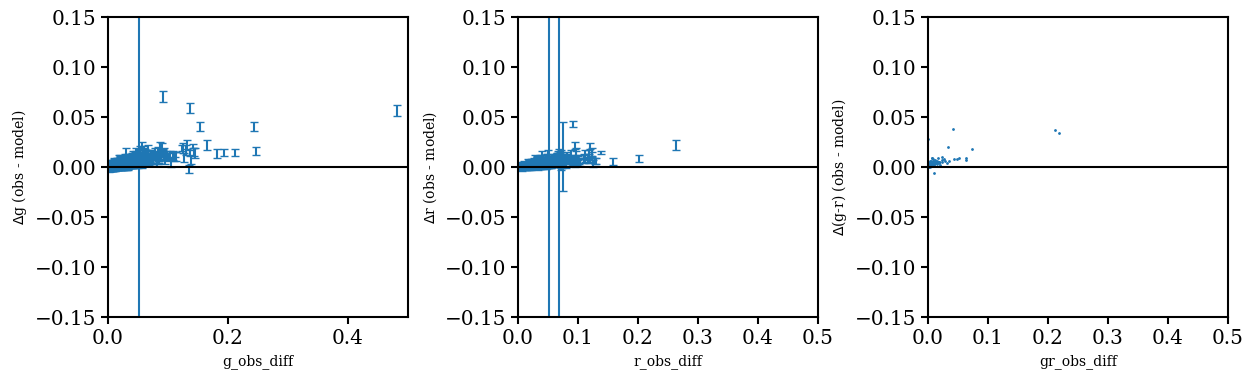

In [93]:
fig,ax = make_subplots(ncol=3,nrow=1,return_fig=True)

ax[0].errorbar( g_model_diff, g_obs_diff - g_model_diff, yerr = result["g_obs_no_emi_err"],ls="none",capsize=3 )
ax[1].errorbar( r_model_diff, r_obs_diff - r_model_diff, yerr = result["r_obs_no_emi_err"],ls="none",capsize=3 )
ax[2].scatter( gr_model_diff,  gr_obs_diff - gr_model_diff,s=1 )

ax[0].set_ylabel(r"$\Delta$g (obs - model)")
ax[1].set_ylabel(r"$\Delta$r (obs - model)")
ax[2].set_ylabel(r"$\Delta$(g-r) (obs - model)")

ax[0].set_xlabel("g_obs_diff")
ax[1].set_xlabel("r_obs_diff")
ax[2].set_xlabel("gr_obs_diff")

for axi in ax:
    axi.plot([0,1],[0,0],color="k")
    axi.set_xlim([0.0,.5])
    axi.set_ylim([-.15,.15])

plt.show()


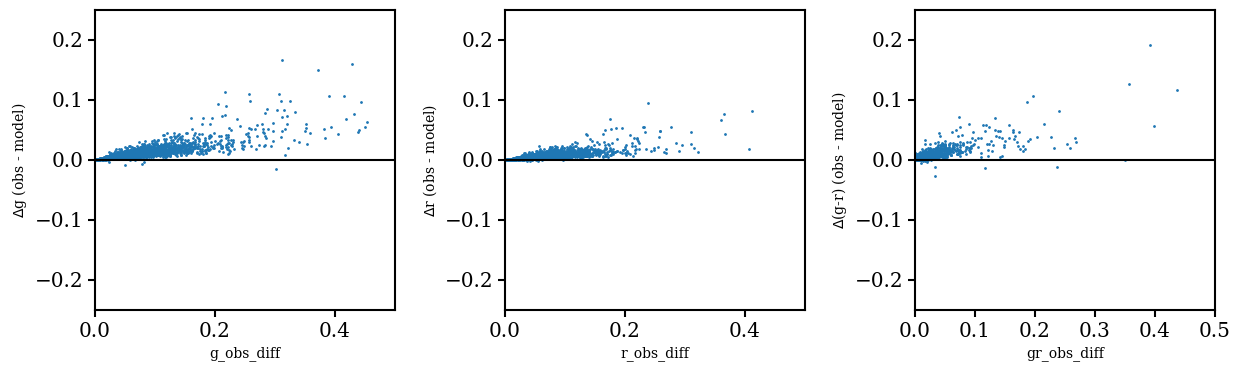

In [44]:
fig,ax = make_subplots(ncol=3,nrow=1,return_fig=True)

ax[0].scatter( g_obs_diff, g_obs_diff - g_model_diff,s=1 )
ax[1].scatter( r_obs_diff, r_obs_diff - r_model_diff,s=1 )
ax[2].scatter( gr_obs_diff,  gr_obs_diff - gr_model_diff,s=1 )

ax[0].set_ylabel(r"$\Delta$g (obs - model)")
ax[1].set_ylabel(r"$\Delta$r (obs - model)")
ax[2].set_ylabel(r"$\Delta$(g-r) (obs - model)")

ax[0].set_xlabel("g_obs_diff")
ax[1].set_xlabel("r_obs_diff")
ax[2].set_xlabel("gr_obs_diff")

for axi in ax:
    axi.plot([0,1],[0,0],color="k")
    axi.set_xlim([0.0,.5])
    axi.set_ylim([-.25,.25])

plt.show()


What this plot is saying is that when the nebular correction is very large, the difference between this correction on observed data and model is also most biased. Specifically, the correction derived from observed data is the higher. This could be due to the contribution of the smooth continuum?? Ahh so indeed, once smooth continuum is added into the mix, the agreement gets better! But the bias trend still remains ... 

TODO: look at high SNR data to see what might be happening, it might point to an explanation of the trend ... 

So to get the filter transformations and k corrections we can use the model fit, but to get the error on the nebular correction, we use the observed spectra.

The question remains is whether the smooth continuum + continuum is a good descriptor of the observed spectra continuum and can trust it at the level of broad band photometry .. 

So after testing on both elg like spectra and high snr spectra, it seems that continuum + smooth is decent for first try, but this bias is puzzling ... but for now, maybe okay to ignore?


In [74]:
result_elg = compute_photometry_catalog_COMPARE(
    main_elg[:1000],
    spectra_h5_path="/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5",
    batch_size=500,ncore=8,verbose=True)

Loading observed spectra from /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5 ...
  Loaded 381740 spectra, wave shape (7781,)
Total objects: 1000, unique FITS files: 377
  Processed 50/377 files
  Processed 100/377 files
  Processed 150/377 files
  Processed 200/377 files
  Processed 250/377 files
  Processed 300/377 files
  Processed 350/377 files
  Processed 377/377 files (done)
Done. 988/1000 with valid obs photometry, 988/1000 with valid model photometry.


In [96]:
## save this as a pickle file!!
result_elg.write("/pscratch/sd/v/virajvm/trash/main_elg_results.fits")

In [102]:


g_model_diff = result_elg["g_model_no_emi"].data - result_elg["g_model_w_emi"].data
g_obs_diff = result_elg["g_obs_no_emi"].data - result_elg["g_obs_w_emi"].data

r_model_diff = result_elg["r_model_no_emi"].data - result_elg["r_model_w_emi"].data
r_obs_diff = result_elg["r_obs_no_emi"].data - result_elg["r_obs_w_emi"].data

gr_model_w_emi = result_elg["g_model_w_emi"].data - result_elg["r_model_w_emi"].data
gr_model_no_emi = result_elg["g_model_no_emi"].data - result_elg["r_model_no_emi"].data

gr_obs_w_emi = result_elg["g_obs_w_emi"].data - result_elg["r_obs_w_emi"].data
gr_obs_no_emi = result_elg["g_obs_no_emi"].data - result_elg["r_obs_no_emi"].data

gr_model_diff = gr_model_no_emi - gr_model_w_emi
gr_obs_diff = gr_obs_no_emi - gr_obs_w_emi


In [103]:
np.where(g_model_diff == np.nanmax(g_model_diff))

(array([45]),)

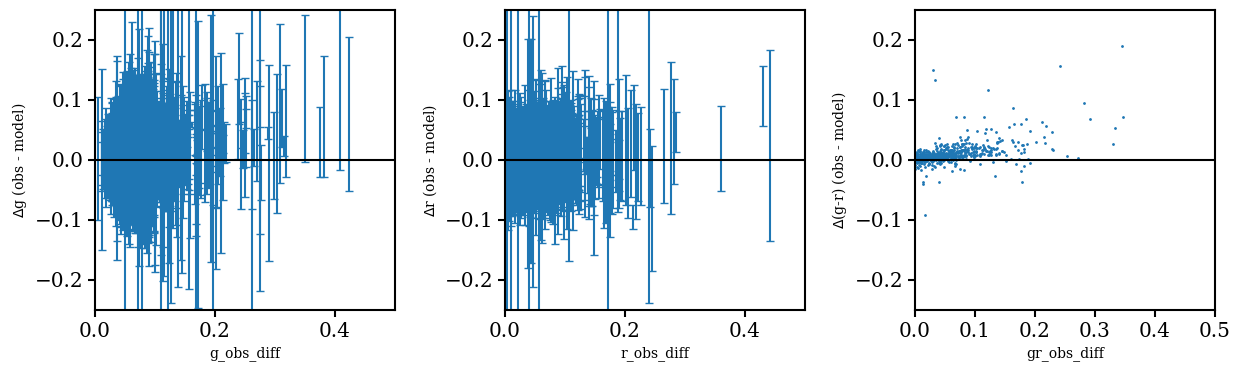

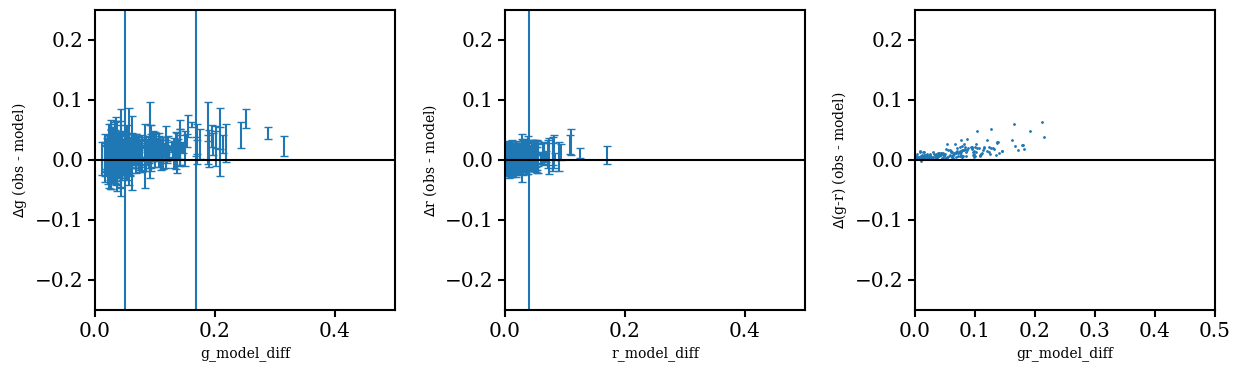

In [117]:
fig,ax = make_subplots(ncol=3,nrow=1,return_fig=True)

ax[0].errorbar( g_model_diff, g_obs_diff - g_model_diff, yerr = result_elg["g_obs_no_emi_err"],ls="none",capsize=3)
ax[1].errorbar( r_model_diff, r_obs_diff - r_model_diff, yerr = result_elg["r_obs_no_emi_err"],ls="none",capsize=3)
ax[2].scatter( gr_model_diff,  gr_obs_diff - gr_model_diff,s=1) #,c=main_elg[:2500]["SNR_R"],cmap="viridis",vmin=1,vmax=2 )

ax[0].set_ylabel(r"$\Delta$g (obs - model)")
ax[1].set_ylabel(r"$\Delta$r (obs - model)")
ax[2].set_ylabel(r"$\Delta$(g-r) (obs - model)")

ax[0].set_xlabel("g_obs_diff")
ax[1].set_xlabel("r_obs_diff")
ax[2].set_xlabel("gr_obs_diff")

for axi in ax:
    axi.plot([0,1],[0,0],color="k")
    axi.set_xlim([-0,.5])
    axi.set_ylim([-.25,.25])

plt.show()

#####

hi_snr_mask = (result_elg["SNR_R"] > 1)


fig,ax = make_subplots(ncol=3,nrow=1,return_fig=True)

ax[0].errorbar( g_model_diff[hi_snr_mask], g_obs_diff[hi_snr_mask] - g_model_diff[hi_snr_mask], yerr = result_elg["g_obs_no_emi_err"][hi_snr_mask],ls="none",capsize=3)
ax[1].errorbar( r_model_diff[hi_snr_mask], r_obs_diff[hi_snr_mask] - r_model_diff[hi_snr_mask], yerr = result_elg["r_obs_no_emi_err"][hi_snr_mask],ls="none",capsize=3)
ax[2].scatter( gr_model_diff[hi_snr_mask],  gr_obs_diff[hi_snr_mask] - gr_model_diff[hi_snr_mask],s=1) #,c=main_elg[:2500]["SNR_R"],cmap="viridis",vmin=1,vmax=2 )

ax[0].set_ylabel(r"$\Delta$g (obs - model)")
ax[1].set_ylabel(r"$\Delta$r (obs - model)")
ax[2].set_ylabel(r"$\Delta$(g-r) (obs - model)")

ax[0].set_xlabel("g_model_diff")
ax[1].set_xlabel("r_model_diff")
ax[2].set_xlabel("gr_model_diff")

for axi in ax:
    axi.plot([0,1],[0,0],color="k")
    axi.set_xlim([-0,.5])
    axi.set_ylim([-.25,.25])

plt.show()


## What is the reason for this systematic bias??

Does the noise array make an impact here?

In [171]:
main_elg[:2500][g_obs_diff > 0.4][:5]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,DIST_SOURCE,LOG_MSTAR_SAGA,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,HALPHA_EW,SNR_R,SNR_B,SNR_Z
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float64,bytes10,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,float32,float32,float32,float32
39627147526015432,sv1,dark,38778,0.3612225327554361,180.38697350025177,False,0.36278692664847845,161.28645881845108,-27.47200731719406,161.28645881845108,-27.47200731719406,DESI J161.2864-27.4720,1997.71826171875,V_CMB,8.308574379283286,8.560768567230474,23.65558433532715,23.63572883605957,23.000762939453125,23.65558433532715,23.63572883605957,23.000762939453125,ELG,32768,TRACTOR_OG,False,0.18788975477218628,1.0 .. 0.0,False,[],39627147526015432,True,331.57986,0.7393044,0.056542628,0.71219873
39627152907306205,sv1,dark,38777,0.09460602540051402,43564.77418136597,False,0.09586698410569117,161.82551918981727,-27.26075463531581,161.82551918981727,-27.26075463531581,DESI J161.8255-27.2607,454.9057922363281,V_CMB,7.2857887338226845,7.520335640528614,22.812950134277344,22.878206253051758,22.618515014648438,22.812950134277344,22.878206253051758,22.618515014648438,ELG,0,TRACTOR_OG,False,0.0,1.0 .. 0.0,False,[],39627152907306205,True,296.0793,1.3261784,0.6309568,1.5344019
39627306670489755,sv1,dark,21075,0.05983039982500137,25003.108475208282,False,0.06008141795692467,87.21071009260083,-20.352616830270627,87.21071009260083,-20.352616830270627,DESI J087.2107-20.3526,278.20623779296875,V_CMB,7.428962903697768,7.629105123257505,21.97650146484375,21.908634185791016,22.05841064453125,21.97650146484375,21.908634185791016,22.05841064453125,ELG,0,TRACTOR_OG,False,0.32912662625312805,1.0 .. 0.0,False,[],39627306670489755,True,680.0931,0.71165925,0.6528568,0.8264656
39627408910846560,main,dark,16865,0.09255793425028254,6028.509949922562,False,0.09140492291403879,9.501177263835485,-15.645798284930445,9.501177263835485,-15.645798284930445,DESI J009.5011-15.6457,432.44091796875,V_CMB,7.65537516630866,7.839025776136667,22.554786682128906,22.434158325195312,22.132347106933594,22.554786682128906,22.434158325195312,22.132347106933594,ELG,0,TRACTOR_OG,False,0.0,1.0 .. 0.0,False,[],39627408910846560,True,156.45422,0.842976,0.46498773,0.66978383
39627468352523239,main,dark,22578,0.09030706036495854,1034.4647474884987,False,0.09008186697294396,66.3080487756816,-13.134819815054872,66.3080487756816,-13.134819815054872,DESI J066.3080-13.1348,425.80322265625,V_CMB,7.4598166377752415,7.662468502886593,22.8723087310791,22.785696029663086,22.518918991088867,22.8723087310791,22.785696029663086,22.518918991088867,ELG,0,TRACTOR_OG,False,0.25168338418006897,1.0 .. 0.0,False,[],39627468352523239,True,114.5839,0.3904037,0.25937095,0.26880226


In [13]:
from fastspec_funcs import DECAM_G, DECAM_R
from astropy.convolution import Gaussian1DKernel, convolve

def compute_photo(wave,flux):
    wlen_f = wave * u.Angstrom
    flux_f = flux * 1e-17 * u.erg / (u.cm**2 * u.s * u.Angstrom)

    result_g = DECAM_G.get_ab_magnitudes(flux_f, wlen_f)['decamDR1noatm-g'].data
    result_r = DECAM_R.get_ab_magnitudes(flux_f, wlen_f)['decamDR1noatm-r'].data

    return result_g, result_r
    

In [14]:
from tqdm.notebook import tqdm

In [37]:
len(main_i)

5036

In [38]:

# tgid_plot = 39627306670489755

all_model  = []
all_obs = []

for tgid_plot in tqdm(main_i[:500]["TARGETID"].data):

    try:
        tgid_mask =(main["TARGETID"] == tgid_plot)
        zred_i = main[tgid_mask]["Z"][0]
        
        cat_path = get_fastspecfit_path(main[tgid_mask]["SURVEY"][0],main[tgid_mask]["PROGRAM"][0],main[tgid_mask]["HEALPIX"][0], 
                                        base_dir="/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/healpix")
        
        ## load the actual spectra and then fastspecfit model fit,
        fits_i = fits.open(cat_path)
        header = fits_i["MODELS"].header
        wavelength = (header["CRVAL1"] + (np.arange(header["NAXIS1"]) - header["CRPIX1"]) * header["CDELT1"])
        model_data = fits_i["MODELS"].data
        
        fastspec_data = fits_i["FASTSPEC"].data
        tgids_file = fastspec_data["TARGETID"]
        
        idx_i = np.where( tgids_file ==  tgid_plot)[0][0]  
        h5_id = np.where( h5_targetid ==  tgid_plot)[0][0]  
    
        all_obs.append( h5_flux[h5_id] )
    
        all_model.append( model_data[idx_i][0]+ model_data[idx_i][1] + model_data[idx_i][2] )
    except:
        all_obs.append( np.ones_like(h5_wave)*np.nan  )
        all_model.append( np.ones_like(h5_wave)*np.nan )
        
        


  0%|          | 0/500 [00:00<?, ?it/s]

In [39]:
model_g, model_r = compute_photo(h5_wave,np.array(all_model)  )

obs_g, obs_r = compute_photo(h5_wave,np.array(all_obs)  )


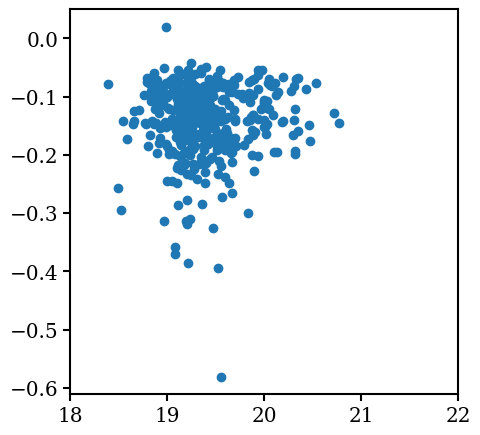

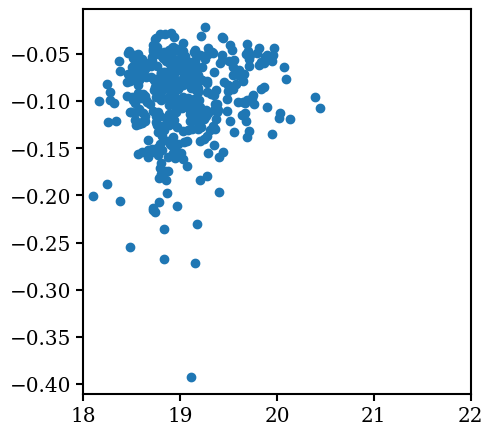

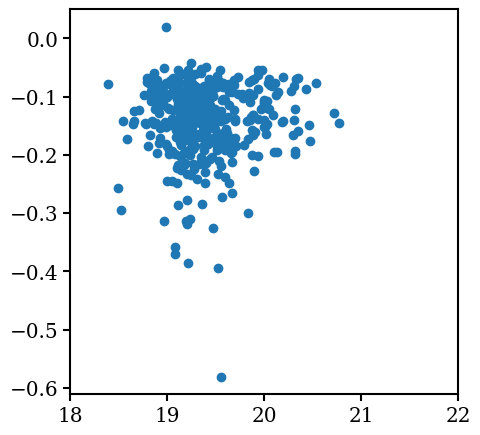

In [42]:
plt.figure(figsize =(5,5))
plt.scatter(obs_g, model_g - obs_g,c=)
plt.xlim([18,22])
plt.show()

plt.figure(figsize =(5,5))
plt.scatter(obs_r, model_r - obs_r)
plt.xlim([18,22])
plt.show()

plt.figure(figsize =(5,5))
plt.scatter(obs_g, model_g - obs_g)
plt.xlim([18,22])
plt.show()



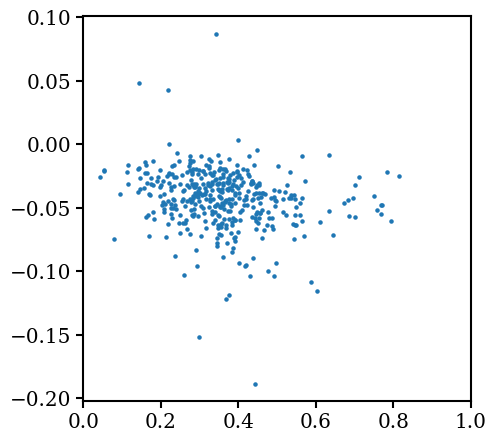

In [47]:
plt.figure(figsize =(5,5))
plt.scatter(obs_g - obs_r,  (model_g - model_r) - (obs_g - obs_r),s=5  ) 
plt.xlim([0,1])
plt.show()

### the stellar continuum template is as is ... 

In [10]:
## THINGS TO LOOK AT, DO THE DIFFERENCES HERE CORRELATE WITH THE BIASES FROM BEFORE??
##


In [11]:
Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/model_photometry_diffs_LOWZ.fits")

TARGETID,g_model_no_emi,r_model_no_emi,g_model_w_emi,r_model_w_emi,g_bass_w_emi,r_bass_w_emi,g_sdss_no_emi,r_sdss_no_emi,g_sdss_z0_no_emi,r_sdss_z0_no_emi,HALPHA_EW,HALPHA_EW_IVAR
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2705768184807424,20.748979440750595,20.55299302969701,20.681508606255115,20.477124837908175,20.689180579178252,20.476866780607335,20.77020495958733,20.550757126103157,20.77210992962163,20.594422140558425,72.25332641601562,0.1281275451183319
2705791102484480,20.52003948046742,20.36703044620946,20.49565639748331,20.335851052687772,20.499311337729594,20.336164689971707,20.53292589118334,20.38627751878508,20.545223538475923,20.407439341671207,28.31350326538086,0.4244726002216339
2705791945539584,21.54024504150012,21.294492472342004,21.519348199022254,21.271155234906416,21.523097893478187,21.271976890822,21.5570423864029,21.314173219464422,21.564201692203262,21.328024779577298,23.108354568481445,0.5813977122306824
2705867015192576,21.718324803022142,21.57058104960951,21.71052705310982,21.553567356168237,21.713048724288512,21.554909724543787,21.737778161913187,21.60893086936062,21.7356563951382,21.60924718511053,18.094589233398438,0.3144835829734802
2705878994124800,21.649414481793293,21.471170156434578,21.608625927826587,21.42743953295475,21.611746667105475,21.430061590608243,21.662142978655012,21.497785494316663,21.675110934252007,21.51477255101519,44.04283905029297,0.06192969158291817
2705896975106048,21.260262565584107,21.115981479684145,21.247205890097014,21.106989347080493,21.250763258122593,21.107475442015783,21.27584294989245,21.129347319994483,21.286405711458546,21.14911762857249,8.28691577911377,2.9883999824523926
2705897356787712,21.24301788178951,21.201465202787464,21.223440618580437,21.16996127048449,21.22403540362482,21.170866904103974,21.249679625393625,21.210292458209143,21.263390902821634,21.23394609062593,36.219486236572266,0.19189044833183289
2705908815626240,20.72615501632439,20.4409860070023,20.556562973106676,20.35407919304831,20.58297210695086,20.35560700519359,20.76065068659359,20.488368809457356,20.735935586131887,20.48140930328318,102.8506088256836,0.08018192648887634
2705920509345792,20.547565119281174,20.516315974973345,20.234118425752683,20.28863168546738,20.249916026496923,20.282919572817537,20.5521898362251,20.526433217589606,20.59296988938842,20.552193247135243,290.5382995605469,0.01108546182513237


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


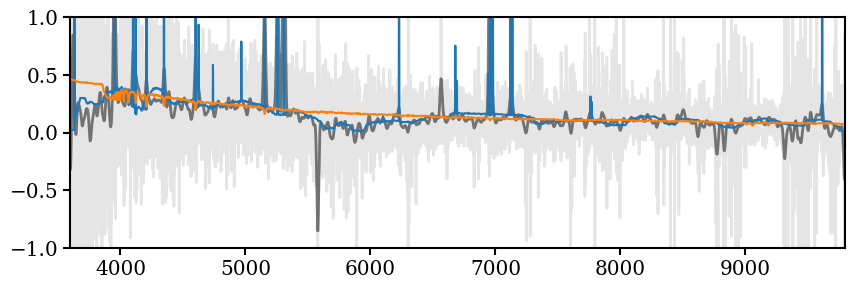

In [204]:

plt.figure(figsize = (10,3))
## let us smooth these fits a bit!
plt.plot(h5_wave, h5_flux[h5_id],color="k",alpha=0.1,lw=2)


##let us do astropy gaussian convolve

plt.plot(h5_wave, convolve( h5_flux[h5_id] , Gaussian1DKernel(10) ),color="k",alpha=0.5,lw=2)


plt.plot(wavelength, model_data[idx_i][0]+ model_data[idx_i][1] + model_data[idx_i][2] )

plt.plot(wavelength, model_data[idx_i][0] )


plt.legend()
plt.ylim([-1,1])

plt.xlim([3600,9800])
plt.show()

In [ ]:
## how do the total model observed photometry compare for each band?? what does it mean if g model is 

In [35]:
# 39627380339251819


In [157]:
tgid_mask = (h5_targetid ==  39627322709513192)
print(np.sum(tgid_mask))
main_mask = (main_i["TARGETID"] == 39627322709513192)

1


In [158]:
temp_actual = measure_photo_batch(h5_wave, h5_flux[tgid_mask], h5_flux_ivar[tgid_mask], zred = main_i[main_mask]["Z"].data )

/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/fastspec_funcs.py:232: RuntimeWarning: divide by zero encountered in true_divide
  w = get_filter_weights(filt_seq[0], wave)


In [159]:
## let us compute these errors by just randomly jittering the spectra and getting the distribution of errors!!

In [160]:
temp_g = []
temp_r = []

for _ in range(500):
    flux_i = np.random.normal(loc= h5_flux[tgid_mask], scale = np.sqrt(1/h5_flux_ivar[tgid_mask]) )

    temp_i = measure_photo_batch(h5_wave, flux_i, h5_flux_ivar[tgid_mask], zred = main_i[main_mask]["Z"].data )

    temp_g.append( temp_i["g_decam"][0] )
    temp_r.append( temp_i["r_decam"][0] )

/tmp/ipykernel_2182730/3757374774.py:5: RuntimeWarning: divide by zero encountered in true_divide
  flux_i = np.random.normal(loc= h5_flux[tgid_mask], scale = np.sqrt(1/h5_flux_ivar[tgid_mask]) )
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/fastspec_funcs.py:233: RuntimeWarning: invalid value encountered in matmul
  flux_phys = flux_raw * 1e-17


In [161]:
temp_actual

{'g_decam': array([19.50818139]),
 'g_decam_err': array([0.00611457]),
 'r_decam': array([19.19954095]),
 'r_decam_err': array([0.00397667])}

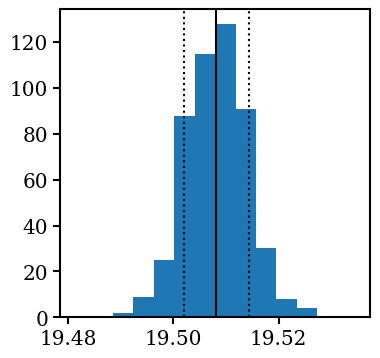

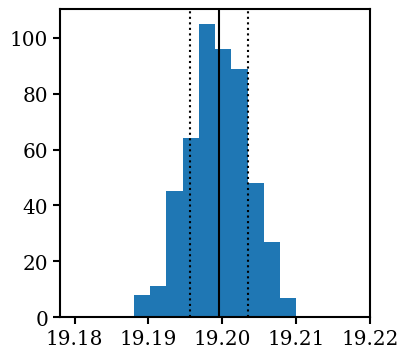

In [162]:
plt.figure(figsize = (4,4))
plt.hist(temp_g)
plt.axvline(temp_actual["g_decam"][0], color="k")
plt.axvline(temp_actual["g_decam"][0] - temp_actual["g_decam_err"][0], color="k",ls="dotted")
plt.axvline(temp_actual["g_decam"][0] + temp_actual["g_decam_err"][0], color="k",ls="dotted")
plt.xlim([np.min(temp_g) - 0.01,np.max(temp_g) + 0.01])
plt.show()

plt.figure(figsize = (4,4))
plt.hist(temp_r)
plt.axvline(temp_actual["r_decam"][0], color="k")
plt.axvline(temp_actual["r_decam"][0] - temp_actual["r_decam_err"][0], color="k",ls="dotted")
plt.axvline(temp_actual["r_decam"][0] + temp_actual["r_decam_err"][0], color="k",ls="dotted")
plt.xlim([np.min(temp_r) - 0.01,np.max(temp_r) + 0.01])
plt.show()

In [2]:
cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")

snr_mask  =  ( (cat["HALPHA_EW"].data * np.sqrt(cat["HALPHA_EW_IVAR"]) ) > 5) & (cat["HALPHA_EW"] > 0)

In [3]:
np.sum(snr_mask)/len(snr_mask)

0.8637257623454785

In [4]:

from desi_lowz_funcs import get_contours

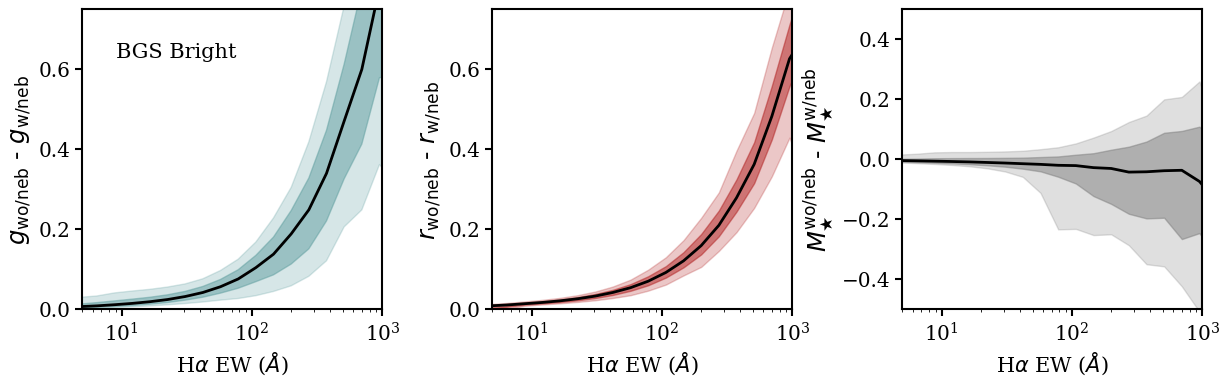

In [19]:
import numpy as np

fig, ax = make_subplots(ncol=3, nrow=1, return_fig=True)

# Log-spaced x bins
x_bins = np.logspace(np.log10(4), np.log10(1.5e3), 20)

# Panel 0
x0 = cat["HALPHA_EW"].data[snr_mask]
y0 = cat["DELTA_MAG_G_NEB"].data[snr_mask]
c0 = get_contours(x0, y0, x_bins, sigs=True)
col0 = "cadetblue"
ax[0].plot(c0["bin_cents"], c0["median"], color="k", lw=2)
ax[0].fill_between(c0["bin_cents"], c0["sig1_low"], c0["sig1_high"], alpha=0.5, color=col0)
ax[0].fill_between(c0["bin_cents"], c0["sig2_low"], c0["sig2_high"], alpha=0.25, color=col0)

# Panel 1
x1 = cat["HALPHA_EW"].data #[snr_mask]
y1 = cat["DELTA_MAG_R_NEB"].data #[snr_mask]
# ax[1].scatter(x1, y1, s=1, alpha=0.3)
col1 = "firebrick"
c1 = get_contours(x1, y1, x_bins, sigs=True)
ax[1].plot(c1["bin_cents"], c1["median"], color="k", lw=2)
ax[1].fill_between(c1["bin_cents"], c1["sig1_low"], c1["sig1_high"], alpha=0.5, color=col1)
ax[1].fill_between(c1["bin_cents"], c1["sig2_low"], c1["sig2_high"], alpha=0.25, color=col1)

# Panel 2
x2 = cat["HALPHA_EW"].data[snr_mask]
y2 = cat["LOGM_M24_FIDU_NEBCORR"].data[snr_mask] - cat["LOGM_M24_FIDU"].data[snr_mask]
# ax[2].scatter(x2, y2, s=1, alpha=0.3)
col2 = "grey"
c2 = get_contours(x2, y2, x_bins, sigs=True)
ax[2].plot(c2["bin_cents"], c2["median"], color="k", lw=2)
ax[2].fill_between(c2["bin_cents"], c2["sig1_low"], c2["sig1_high"], alpha=0.5, color=col2)
ax[2].fill_between(c2["bin_cents"], c2["sig2_low"], c2["sig2_high"], alpha=0.25, color=col2)

for axi in ax:
    axi.set_xlim([5, 1e3])
    axi.set_xscale("log")
    axi.set_ylim([0, .75])
    axi.set_xlabel(r"H$\alpha$ EW ($\AA$)",fontsize = 15)
    
ax[2].set_ylim([-0.5, 0.5])

ax[0].set_ylabel(r"$g_{\rm wo/neb}$ - $g_{\rm w/neb}$",fontsize = 17.5)
ax[1].set_ylabel(r"$r_{\rm wo/neb}$ - $r_{\rm w/neb}$",fontsize = 17.5)
ax[2].set_ylabel(r"$M_{\bigstar}^{\rm wo/neb}$ - $M_{\bigstar}^{\rm w/neb}$",fontsize = 17.5)

ax[0].text(9,0.63,"BGS Bright",fontsize = 15)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/neb_corr_bgsb_plot.pdf",bbox_inches="tight")

plt.show()


In [20]:
# 39627857785262391

## Plotting the fastspec template!

In [135]:

tgid_plot = 39627479563901933

tgid_mask =(main["TARGETID"] == tgid_plot)
zred_i = main[tgid_mask]["Z"][0]

cat_path = get_fastspecfit_path(main[tgid_mask]["SURVEY"][0],main[tgid_mask]["PROGRAM"][0],main[tgid_mask]["HEALPIX"][0], 
                                base_dir="/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/healpix")


## load the actual spectra and then fastspecfit model fit,
fits_i = fits.open(cat_path)
header = fits_i["MODELS"].header
wavelength = (header["CRVAL1"] + (np.arange(header["NAXIS1"]) - header["CRPIX1"]) * header["CDELT1"])
model_data = fits_i["MODELS"].data

fastspec_data = fits_i["FASTSPEC"].data
tgids_file = fastspec_data["TARGETID"]

idx_i = np.where( tgids_file ==  tgid_plot)[0][0]  
h5_id = np.where( h5_targetid ==  tgid_plot)[0][0]  



In [140]:
shorten = -1

cont_width=15

LINE_WINDOWS = {
    "Halpha": (6558.0 - shorten, 6571.0 + shorten,5),
    "NII_6548": (6545.0 + 1, 6555.0 - 1, 5),
    "NII_6583": (6578.0 + 2, 6592.0 - 2,cont_width),
    "Hbeta": (4848.0 + 10, 4878.0 - 10, 3),
    "OIII_4959": (4945.0 + 10, 4975.0 - 10,5),
    "OIII_5007": (4990.0 + 10, 5025.0 - 10,5),
    "OII": (3710.0 + 12, 3750.0 - 14,5),
    "SII": (6700.0 + 12, 6755.0 - 16 , 5),
}


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


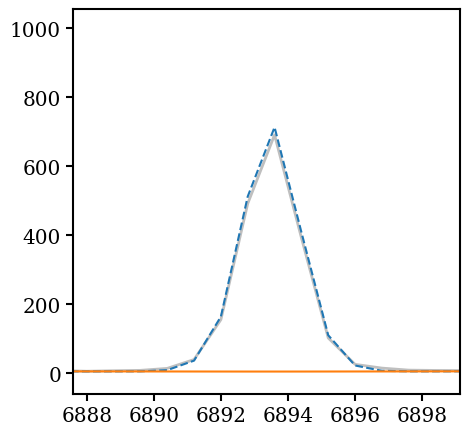

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


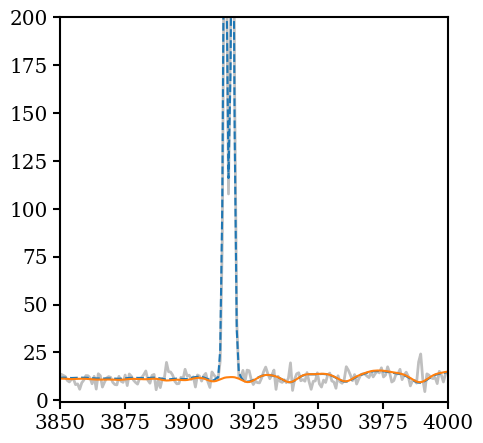

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


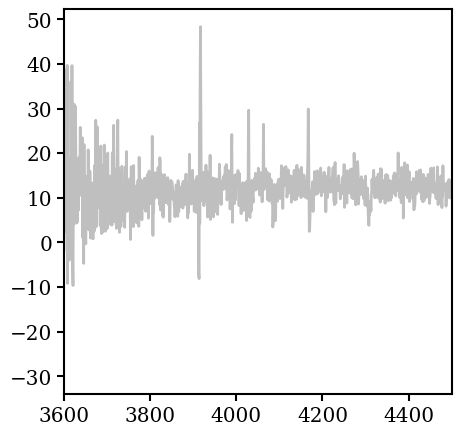

In [152]:

plt.figure(figsize = (5,5))

## let us smooth these fits a bit!

plt.plot(h5_wave, h5_flux[h5_id],color="k",alpha=0.25,lw=2)

plt.plot(wavelength, model_data[idx_i][2] + model_data[idx_i][1] + model_data[idx_i][0],ls="--")

plt.plot(wavelength, model_data[idx_i][0]+ model_data[idx_i][1])

plt.legend()
# plt.ylim([-1,3])
plt.xlim([LINE_WINDOWS["Halpha"][0] * (1+zred_i),LINE_WINDOWS["Halpha"][1] * (1+zred_i) ])
plt.show()


####

plt.figure(figsize = (5,5))

## let us smooth these fits a bit!

plt.plot(h5_wave, h5_flux[h5_id],color="k",alpha=0.25,lw=2)

plt.plot(wavelength, model_data[idx_i][2] + model_data[idx_i][1] + model_data[idx_i][0],ls="--")

plt.plot(wavelength, model_data[idx_i][0] )

plt.legend()
plt.ylim([-1,200])
plt.xlim([3850,4000 ])
plt.show()



####


plt.figure(figsize = (5,5))

## let us smooth these fits a bit!

plt.plot(h5_wave, h5_flux[h5_id] - model_data[idx_i][2] ,color="k",alpha=0.25,lw=2)

plt.legend()
# plt.ylim([-1,3])
plt.xlim([3600,4500 ])
plt.show()


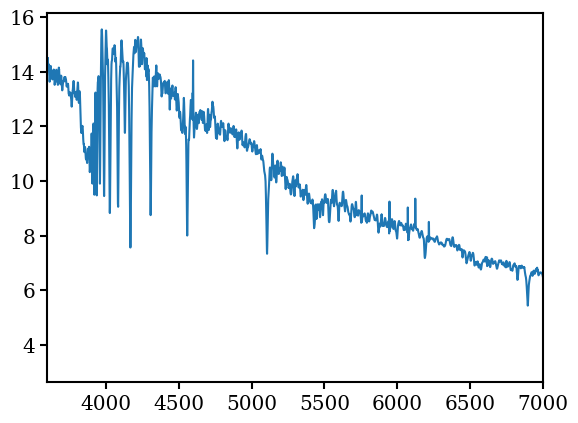

In [147]:
# plt.plot(wavelength, model_data[idx_i][0] + model_data[idx_i][1] )
plt.plot(wavelength, model_data[idx_i][0]  )
plt.xlim([3600,7000])
plt.show()

### K corrections and bass -> decam -> sdss corrections!!

In [ ]:
# 

In [3]:
# lowz_diffs = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/model_photometry_diffs_LOWZ.fits")
# lowz_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits")
lowz_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")

# 

In [4]:
lowz_cat["LOGM_M24_FIDU"].max()

9.499969294211642

In [5]:
lowz_cat["LOGM_M24_FIDU_CORR"].max()

9.249998361931784

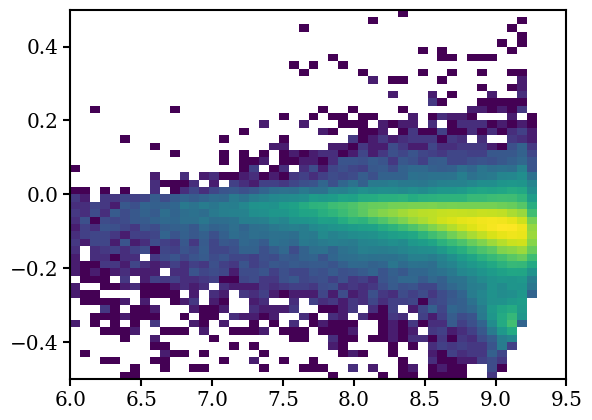

In [6]:
plt.hist2d(lowz_cat["LOGM_M24_FIDU_CORR"], lowz_cat["LOGM_M24_FIDU_CORR"] - lowz_cat["LOGM_M24_FIDU"],range=((6,9.5),(-.5,0.5)),
          bins=50,norm=LogNorm() )
plt.xlim([6,9.5])
plt.show()

## PLOT THESE K CORRECTIONS AS A FUNCTION OF REDSHIFT!!


In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import cmasher as cmr
from desi_lowz_funcs import g_kcorr, r_kcorr, get_contours, make_alternating_plot


In [26]:
bgsb_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")
bgsf_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_faint_filter_zsucc_zrr03_allfracflux_INT_V2_NEBCORR.fits")
lowz_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits")


In [27]:
tot_cat = vstack([bgsb_cat, bgsf_cat, lowz_cat ])

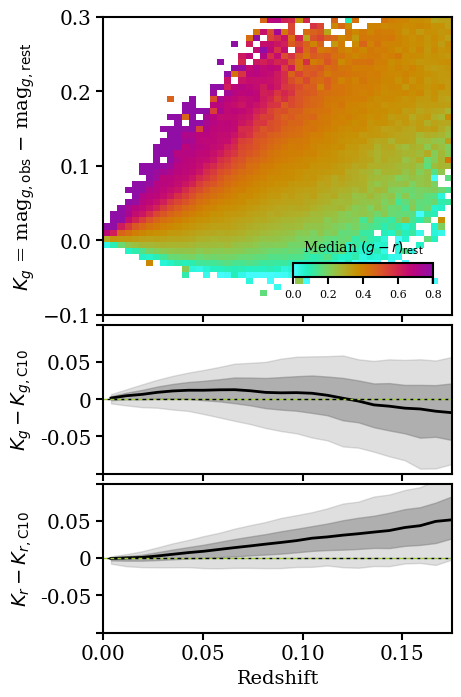

In [158]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from desi_lowz_funcs import g_kcorr, r_kcorr

zred_max = 0.175
delta_ylim = 0.1

# --- Derived quantities ---
x = tot_cat["Z"]
y = -1 * tot_cat["DELTA_MAG_G_KCORR"]
c = tot_cat["MAG_G_SDSS_Z0"] - tot_cat["MAG_R_SDSS_Z0"]

mag_g_sdss_obs = tot_cat["MAG_G_SDSS_Z0"] - tot_cat["DELTA_MAG_G_KCORR"]
mag_r_sdss_obs = tot_cat["MAG_R_SDSS_Z0"] - tot_cat["DELTA_MAG_R_KCORR"]
gr_sdss_obs    = mag_g_sdss_obs - mag_r_sdss_obs

g_kcorr_2010 = g_kcorr(gr_sdss_obs, tot_cat["Z"])
r_kcorr_2010 = r_kcorr(gr_sdss_obs, tot_cat["Z"])

resid_g = g_kcorr_2010 - y
resid_r = r_kcorr_2010 + tot_cat["DELTA_MAG_R_KCORR"]

# --- Bin edges ---
x_bins_2d = np.linspace(0, zred_max, 50)
y_bins_2d = np.linspace(-0.1, 0.3, 50)
x_bins_1d = np.linspace(0, zred_max + 0.05, 30)

# --- 2D histogram stat ---
from scipy.stats import binned_statistic_2d

stat, x_edge, y_edge, _ = binned_statistic_2d(
    x, y, c, statistic="median", bins=[x_bins_2d, y_bins_2d]
)

# --- Figure layout ---
fig, axes = plt.subplots(
    3, 1, figsize=(4.5, 8),
    gridspec_kw={"height_ratios": [2, 1, 1]},
    sharex=True
)
fig.subplots_adjust(hspace=0.05)

col_g = "grey"
col_r = "grey"

# ── Panel 0 : 2D histogram ────────────────────────────────────────────────
ax0 = axes[0]
im = ax0.pcolormesh(x_edge, y_edge, stat.T, cmap=cmr.tropical_r, vmin=0., vmax=0.8, rasterized=True)
ax0.set_ylim(-0.1, 0.3)
ax0.set_ylabel(r"$K_g$ = mag$_{g,\rm obs}$ $-$ mag$_{g,\rm rest}$", fontsize=14)
ax0.tick_params(labelbottom=False)

# Colorbar inset — top-right corner, fully inside ax0
cax = inset_axes(ax0,
                 width="40%", height="5%",
                 loc="upper left",
                 bbox_to_anchor=(0.545, -0.825, 1, 1),  # (x0, y0, width, height) in axes fraction
                 bbox_transform=ax0.transAxes,
                 borderpad=0)
cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
cbar.set_label(r"Median $(g-r)_{\rm rest}$", fontsize=10, labelpad=-44)
cbar.ax.tick_params(labelsize=8)
cax.set_zorder(5)   # draw on top of pcolormesh

# ── Panel 1 : g-band residual ─────────────────────────────────────────────
ax1 = axes[1]
cg = get_contours(x.data, resid_g.data, x_bins_1d, sigs=True)
ax1.plot(cg["bin_cents"], cg["median"], color="k", lw=2)
ax1.fill_between(cg["bin_cents"], cg["sig1_low"], cg["sig1_high"],
                 alpha=0.5, color=col_g, label=r"$1\sigma$")
ax1.fill_between(cg["bin_cents"], cg["sig2_low"], cg["sig2_high"],
                 alpha=0.25, color=col_g, label=r"$2\sigma$")
xgrid = np.linspace(0, zred_max, 100)
make_alternating_plot(ax1, xgrid, 0 * xgrid, dash_len=1, color_1="yellowgreen", color_2="k", lw=1)
ax1.set_ylim(-delta_ylim, delta_ylim)
ax1.set_ylabel(r"$K_{g} - K_{g,\rm C10}$", fontsize=14)
ax1.tick_params(labelbottom=False)

# ── Panel 2 : r-band residual ─────────────────────────────────────────────
ax2 = axes[2]
cr = get_contours(x.data, resid_r.data, x_bins_1d, sigs=True)
ax2.plot(cr["bin_cents"], cr["median"], color="k", lw=2)
ax2.fill_between(cr["bin_cents"], cr["sig1_low"], cr["sig1_high"],
                 alpha=0.5, color=col_r, label=r"$1\sigma$")
ax2.fill_between(cr["bin_cents"], cr["sig2_low"], cr["sig2_high"],
                 alpha=0.25, color=col_r, label=r"$2\sigma$")
make_alternating_plot(ax2, xgrid, 0 * xgrid, dash_len=1, color_1="yellowgreen", color_2="k", lw=1)
ax2.set_ylim(-delta_ylim, delta_ylim)
ax2.set_ylabel(r"$K_{r} - K_{r,\rm C10}$", fontsize=14)
ax2.set_xlabel(r"Redshift", fontsize=14)

for axi in [ax1, ax2]:
    axi.set_yticks([-0.1, -0.05, 0, 0.05, 0.1])
    axi.set_yticklabels(["", "-0.05", "0", "0.05", ""])

ax2.set_xlim(0, zred_max)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/k_correction_comp.pdf",bbox_inches="tight")

plt.show()

Test: difference between sdss and decam filters as a function of color etc ... derive those transformations ...

the appendix b of dey et al. imaging paper has color transformations for stars. 

Comparing the different stellar mass estimates!!

Compare only objects from BGS and LOWZ. No ELG. Also show median value with 16-84 percentile error bar at fixed points?

TODO: To FASTSPEC add stellar mass estimates and rename it to some other HDU? Also, move the SAGA stellar mass to a different 


## Compare stellar masses!!

In [108]:
main = main_all[(main_all["DWARF_MASKBIT"] == 0) & (main_all["MAG_TYPE"] == "TRACTOR_OG") & (main_all["SAMPLE"] != "ELG")]


In [109]:
fastspec = fastspec_all[(main_all["DWARF_MASKBIT"] == 0) & (main_all["MAG_TYPE"] == "TRACTOR_OG") & (main_all["SAMPLE"] != "ELG")]


In [110]:
# # filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# # # Option 1: load the MAIN extension directly as an Astropy Table
# # main =  Table.read(filename, hdu="MAIN")


# # ##load the bgs bright, faint and lowz catalog and select only the clean objects
# # bgsb_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")
# # bgsf_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_faint_filter_zsucc_zrr03_allfracflux_INT_V2_NEBCORR.fits")
# # lowz_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits")

# # def process_cat(temp):
# #     mask = (temp["FRACFLUX_G"] < 0.2) & (temp["FRACFLUX_R"] < 0.2) & (temp["FRACFLUX_Z"] < 0.2) #& (temp["LOGM_M24_FIDU_NEBCORR_ERR"] < 0.5)
# #     temp_f = temp[mask]["TARGETID","RA","DEC","DIST_MPC_FIDU", "LOGM_M24_FIDU_CORR","Z"]
# #     print(len(temp), len(temp_f) )
# #     return temp_f

# bgsb_cat_i = process_cat(bgsb_cat)
# bgsf_cat_i = process_cat(bgsf_cat)
# lowz_cat_i = process_cat(lowz_cat)

# main =  vstack([bgsb_cat_i, bgsf_cat_i, lowz_cat_i])


In [111]:
# fastspec

In [112]:
import fitsio

columns = ['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'MASS_CG','MASSERR_CG']

hu_cat = fitsio.read("/global/cfs/cdirs/desi/public/dr1/vac/dr1/stellar-mass-emline/v1.0/dr1_galaxy_stellarmass_lineinfo_v1.0.fits", ext=1, columns=columns)

In [113]:
print(len(hu_cat))

# Propagate linear error to log space: σ_log = σ / (M * ln(10))
hu_cat_ms_err = hu_cat['MASSERR_CG'] / (hu_cat['MASS_CG'] * np.log(10))

hu_cat = hu_cat[ hu_cat_ms_err < 0.25]
print(len(hu_cat))


14706085


/tmp/ipykernel_1194756/1581172412.py:4: RuntimeWarning: invalid value encountered in true_divide
  hu_cat_ms_err = hu_cat['MASSERR_CG'] / (hu_cat['MASS_CG'] * np.log(10))


11509174


In [119]:
##match with the entire catalog
## what does this catalog assume for cosmology?
## According to their paper, they WMAP7 flat cosmology .. how does that impact distance??
gswlc_cat = ascii.read("/pscratch/sd/v/virajvm/desi2_lowz_data/catalogs/GSWLC-X2.dat")
iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
gswlc = SkyCoord(np.array(gswlc_cat["RA"])*u.degree, np.array(gswlc_cat["DEC"])*u.degree  )
idx, d2d, _ = iron.match_to_catalog_sky(gswlc)
main_gswlc_match = main[d2d.arcsec < 1]
gswlc_match = gswlc_cat[idx][d2d.arcsec < 1]

print(len(main_gswlc_match))

##these are stellar masses from Hu Zhou XMPG paper. They also use CIGALE here and no AGN is used
#they assume flat ΛCDM cosmology with ΩΛ = 0.7, Ωm = 0.3, and H0 = 70 km s−1 Mpc−1
# hu_cat= Table.read("/global/cfs/cdirs/desi/users/dscholte/data_to_share/sample_catalog_viraj_29052024.fits")
iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
hu = SkyCoord(np.array(hu_cat["TARGET_RA"])*u.degree, np.array(hu_cat["TARGET_DEC"])*u.degree  )
idx, d2d, _ = iron.match_to_catalog_sky(hu)
main_hu_match = main[d2d.arcsec < 1]
hu_match = hu_cat[idx][d2d.arcsec < 1]

print(len(main_hu_match))



3174
263423


In [13]:
# ##FASTSPECFIT
# fspec_save_path  = "/pscratch/sd/v/virajvm/catalog/fastspec_mstar_match.fits"
# overwrite=True
# if os.path.exists(fspec_save_path.replace(".fits","_fspec.npy")) and overwrite==False:
#     print("Reading pre-matched fastspecfit catalog!")
#     fspec_mstar_f = np.load(fspec_save_path.replace(".fits","_fspec.npy"))

#     main_fspec_match = Table.read(fspec_save_path.replace(".fits","_main.fits"))
    
# else:
#     print("Reading fastspecfit!")
#     iron_vac = fits.open("/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron.fits")
#     fspec_mstar = iron_vac[1].data["LOGMSTAR"]
#     fspec_ra = iron_vac[2].data["RA"]
#     fspec_dec = iron_vac[2].data["DEC"]
#     catalog = SkyCoord(ra= fspec_ra* u.degree, dec= fspec_dec*u.degree )
#     c = SkyCoord(ra=np.array(main["RA"])*u.degree, dec=np.array(main["DEC"])*u.degree )
#     idx, d2d, d3d = c.match_to_catalog_sky(catalog)
#     fspec_mstar_f = fspec_mstar[idx][d2d.arcsec < 1]
#     main_fspec_match = main[d2d.arcsec < 1]
    
#     print("Finished matching fastspecfit!")

#     np.save(fspec_save_path.replace(".fits","_fspec.npy"),  fspec_mstar_f)
#     main_fspec_match.write(fspec_save_path.replace(".fits","_main.fits"),overwrite=True)
    
# print(f"Matched {len(fspec_mstar_f)} galaxies with fastspecfit")
    
# ## save these two matched catalogs so we do not have to always run this!!

In [14]:
# #3 cross matching with COSMOS catalog
# ## need the photo-z to also be similar

# import fitsio

# cols = ["ALPHA_J2000", "DELTA_J2000", "lp_zBEST", "lp_mass_med", "lp_mass_best", "lp_zMinChi2", "lp_zPDF"]

# cosmos2020_cat = fitsio.read("/pscratch/sd/v/virajvm/catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits", columns=cols)

# cosmos2020_cat = Table(cosmos2020_cat)

In [15]:
# iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
# c20 = SkyCoord(np.array(cosmos2020_cat["ALPHA_J2000"])*u.degree, np.array(cosmos2020_cat["DELTA_J2000"])*u.degree  )
# idx, d2d, _ = iron.match_to_catalog_sky(c20)
# main_cos20_match = main[d2d.arcsec < 1]
# cos20_match = cosmos2020_cat[idx][d2d.arcsec < 1]

# ## similar to zou et al 2024, let us identify objects with consistent redshifts
# good_mask = (np.abs(cos20_match["lp_zPDF"] - main_cos20_match["Z"]) / (1 + main_cos20_match["Z"]) < 0.01)

# print(np.sum(good_mask))

# main_cos20_match = main_cos20_match[good_mask]
# cos20_match = cos20_match[good_mask]


In [16]:
# plt.scatter( main_cos20_match["LOG_MSTAR_M24"].data, main_cos20_match["LOG_MSTAR_M24"].data - cos20_match["lp_mass_best"].data)
# plt.xlim([6,9.25])
# plt.ylim([-0.65,0.65])
# plt.show()

In [17]:
# import pandas as pd
# import numpy as np

# colspecs = [
#     (0, 6),     # IDX
#     (7, 15),    # RAdeg
#     (16, 24),   # DEdeg
#     (166, 173), # logMstarMed
# ]
# colnames = ['IDX', 'RA', 'DEC', 'logMstarMed']

# df = pd.read_fwf(
#     '/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/mstar_catalog/physpar.dat',
#     colspecs=colspecs,
#     names=colnames,
#     na_values=['-', '--', '---', '----', '-----', 'nan', 'NaN', ''],
#     dtype={'logMstarMed': str},  # read as str first to safely coerce
# )

# # Coerce to float, turning any remaining non-numeric strings into NaN
# df['logMstarMed'] = pd.to_numeric(df['logMstarMed'], errors='coerce')

# # Drop rows with missing stellar mass
# df = df.dropna(subset=['logMstarMed'])

# # Ensure float dtype
# df['logMstarMed'] = df['logMstarMed'].astype(float)

# physpar_tab = Table.from_pandas(df)

# physpar_tab = physpar_tab[physpar_tab["logMstarMed"] > 0]

# print(f"Loaded {len(physpar_tab)} galaxies")
# print(f"\nRA range:        {physpar_tab['RA'].min():.4f} - {physpar_tab['RA'].max():.4f} deg")
# print(f"DEC range:       {physpar_tab['DEC'].min():.4f} - {physpar_tab['DEC'].max():.4f} deg")
# print(f"logMstar range:  {physpar_tab['logMstarMed'].min():.4f} - {physpar_tab['logMstarMed'].max():.4f}")
# print(f"logMstar dtype:  {physpar_tab['logMstarMed'].dtype}")

In [18]:
# iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
# pcat = SkyCoord(np.array(physpar_tab["RA"])*u.degree, np.array(physpar_tab["DEC"])*u.degree  )
# idx, d2d, _ = iron.match_to_catalog_sky(pcat)
# main_pcat_match = main[d2d.arcsec < 1]
# pcat_match = physpar_tab[idx][d2d.arcsec < 1]

In [19]:
# plt.figure(figsize = (5,5))
# plt.scatter(main_pcat_match["LOG_MSTAR_M24"].data, main_pcat_match["LOG_MSTAR_M24"].data- pcat_match["logMstarMed"].data,s=0.1)
# plt.xlim([6,9])
# plt.ylim([-0.65,0.65])
# plt.show()

In [20]:
import cmasher as cmr
from scipy.stats import median_abs_deviation

def measure_bias_scatter(quant_1, quant_2):
    '''
    Meausure the median of quant_1 - quant_2 and the scatter in this difference. We restrict ourselves to objects
    '''

    quant_1f = quant_1[~np.isnan(quant_1) & ~np.isnan(quant_2) ]
    quant_2f = quant_2[~np.isnan(quant_2) & ~np.isnan(quant_2) ]

    med_val = np.median(quant_1f - quant_2f)
    scatters = quant_1f - quant_2f - med_val

    sigma =  median_abs_deviation(scatters, scale='normal')

    print(med_val, sigma)
    return med_val, sigma


In [21]:
from desi_lowz_funcs import make_alternating_plot

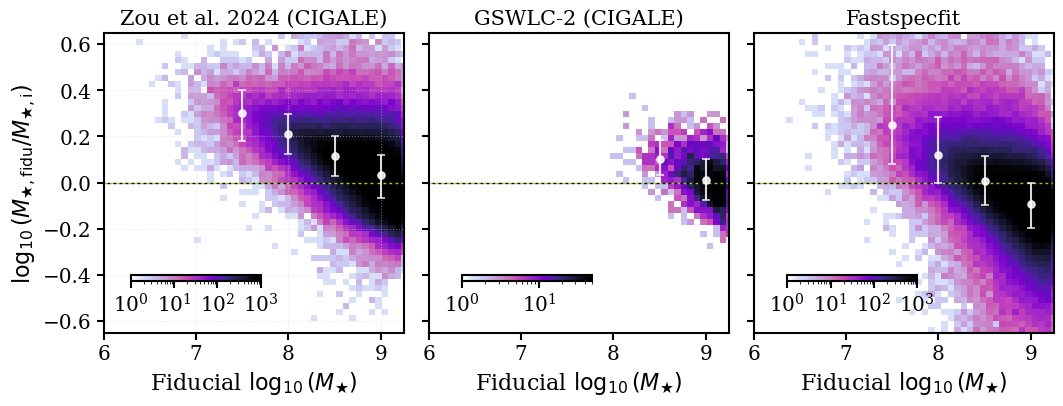

In [23]:
ax = make_subplots(ncol = 3,nrow = 1,col_spacing = 0.25)

title_size = 15

xmstar = "LOG_MSTAR_M24" 

ylim = 0.65

cmap = cmr.gothic_r.copy()
cmap.set_under(alpha=0.)

####
xpos = 7.1
ypos = 6.25
fsize = 14

#the 0.03 offset is taking roughly into account the differing cosmologies

ax_id = 0
ax[ax_id].set_title(r"Zou et al. 2024 (CIGALE)",fontsize = title_size )
h, xedges, yedges, im=ax[ax_id].hist2d(main_hu_match[xmstar],main_hu_match[xmstar] - (np.log10(hu_match["MASS_CG"]) + 0.03),range= ( (6,9.5),(-ylim,ylim)),bins= 50,norm=LogNorm(vmin=1,vmax=1000) ,cmap=cmap, rasterized=True)

# bias, scatter = measure_bias_scatter(main_hu_match[xmstar].data,hu_match["LOGMSTAR_HU"] + 0.03)

# ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

 # Create a colorbar
cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.04,   # Left position
    0.26,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])

###

#the 0.03 offset is taking into account the differing cosmologies

ax_id = 1
ax[ax_id].set_title(r"GSWLC-2 (CIGALE)",fontsize = title_size )
h, xedges, yedges, im=  ax[ax_id].hist2d(main_gswlc_match[xmstar],main_gswlc_match[xmstar] - (gswlc_match["LOGMSTAR"] + 0.03),range= ( (6,9.5),(-ylim,ylim)),bins= 50,norm=LogNorm(vmin=1, vmax=50) ,cmap=cmap, rasterized=True)

# bias, scatter = measure_bias_scatter(main_gswlc_match[xmstar].data,gswlc_match["LOGMSTAR"].data + 0.03)
# ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

 # Create a colorbar
cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.295,   # Left position
    0.26,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])    

# #######
# note that fastspecfit stellar masses are in h = 1 units, so we need to modify them!!
hubble_val = 0.67 

ax_id = 2
ax[ax_id].set_title(r"Fastspecfit",fontsize = title_size )
h, xedges, yedges, im =  ax[ax_id].hist2d(main[xmstar],main[xmstar] - (fastspec["LOGMSTAR"] - 2 * np.log10(hubble_val) ),range= ( (6,9.5),(-ylim,ylim)),bins= 50,norm=LogNorm(vmin=1, vmax=1000) ,cmap=cmap, rasterized=True)

# bias, scatter = measure_bias_scatter(main_fspec_match[xmstar].data,fspec_mstar_f - 2 * np.log10(hubble_val))
# ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.545,   # Left position
    0.26,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])

# #######
# ##note that I am plotting the SAGA mass key here for, but am offseting it as I want to compare it with Bell et a. 2003 relation (see equation 1 in de los reyes et al. 2025)

# ax_id = 3
# ax[ax_id].set_title(r"Bell et al. 2003 ($g-r$ based)",fontsize = title_size )
# h, xedges, yedges, im =  ax[ax_id].hist2d(main[xmstar], main[xmstar] - (main["LOG_MSTAR_SAGA"] + (1.461 - 1.254) ) ,range= ( (6,9.5),(-ylim,ylim)),bins= 50,norm=LogNorm(vmin=1, vmax=1000) ,cmap=cmap, rasterized=True)
# # ax[ax_id].scatter(main_cos20_match[xmstar], cos20_match["lp_mass_med"])

# # bias,scatter = measure_bias_scatter(main[xmstar], main["LOG_MSTAR_SAGA"] + (1.461 - 1.254)) 
# # ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

#  # Create a colorbar
# cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
# cbar.ax.set_position([
#     0.795,   # Left position
#     0.26,  # Top position
#     ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
#     0.02  # Height (thin bar)
# ])

for i,axi in enumerate(ax):
    axi.set_xlim([6,9.25])
    axi.set_ylim([-ylim,ylim])
    
    axi.set_xlabel(r"Fiducial $\log_{10}(M_{\bigstar})$",size= 16)
    ax[0].set_ylabel(r"$\log_{10}(M_{\bigstar, \rm fidu} / M_{\bigstar, \rm i})$",size= 16)
    ax[0].grid(ls = ":",color = "lightgrey",alpha = 0.5)
    
    xgrid = np.linspace(6,9.25,100)
    make_alternating_plot(ax[i],xgrid,0*xgrid,dash_len=1,color_1="yellowgreen",color_2="k",lw=1)

    # --- binned median + 16/84 percentile error bars ---
    # Reconstruct the y-data for each panel
    if i == 0:
        xdata = main_hu_match[xmstar]
        ydata = main_hu_match[xmstar] - (np.log10(hu_match["MASS_CG"]) + 0.03)
    elif i == 1:
        xdata = main_gswlc_match[xmstar]
        ydata = main_gswlc_match[xmstar] - (gswlc_match["LOGMSTAR"] + 0.03)
    elif i == 2:
        xdata = main[xmstar]
        ydata = main[xmstar] - (fastspec["LOGMSTAR"] - 2 * np.log10(hubble_val))
    # elif i == 3:
    #     break
    #     # xdata = main[xmstar]
        # ydata = main[xmstar] - (main["LOG_MSTAR_SAGA"] + (1.461 - 1.254))

    xdata = np.asarray(xdata)
    ydata = np.asarray(ydata)

    bin_width = 0.2
    for xcen in [7.5,8,8.5, 9]:
        mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
        if mask.sum() > 100:
            med = np.median(ydata[mask])
            p16 = np.percentile(ydata[mask], 16)
            p84 = np.percentile(ydata[mask], 84)

            if i == 3:
                axi.errorbar(xcen, med,
                             yerr=[[med - p16], [p84 - med]],
                             fmt='none', color='white',
                             ecolor='white', elinewidth=1.5, capsize=3, zorder=10, alpha=0.85)
            else:
                axi.errorbar(xcen, med,
                             yerr=[[med - p16], [p84 - med]],
                             fmt='o', color='white', markeredgecolor='white',
                             markeredgewidth=1.2, markersize=5, alpha=0.85,
                             ecolor='white', elinewidth=1.5, capsize=3, zorder=10)

    if i != 0:
        axi.set_yticklabels([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stellar_mass_comp.pdf",bbox_inches="tight")
plt.show()



In [58]:
2*np.log10(hubble_val)

-0.34785039459834705

In [59]:
main["ASSOCIATED_TARGETIDS"][0]

array([], dtype=int64)

## Make a plot of the median difference between fiducial and various photometric stellar mass estimates!!

In [82]:
# bgsb_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")

# idx, d2d, _ = match_c_to_catalog(c_cat = main, catalog_cat=bgsb_cat)

# bgsb_match = bgsb_cat[idx][d2d.arcsec<  1]
# main_match = main[d2d.arcsec<  1]

# ## THEESE AGREE WHICH IS GOOD!!

# plt.hist(bgsb_match["LOGM_M24_FIDU_CORR"] - main_match["LOG_MSTAR_M24"],range=(-0.5,0.5),bins=100)
# plt.xlim([-.5,0.5])
# plt.show()

# print(np.median(bgsb_match["LOGM_M24_FIDU_CORR"] - main_match["LOG_MSTAR_M24"]))


In [114]:
from desi_lowz_funcs import get_stellar_mass_mia
from desi_lowz_funcs import get_stellar_mass



In [115]:
fastspec[:2]

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,LOGMSTAR,MAG_G_FIBER_NOEMI,MAG_R_FIBER_NOEMI,MAG_G_FIBER_NOEMI_ERR,MAG_R_FIBER_NOEMI_ERR,MAG_G_DECAM_MODEL_NOEMI,MAG_R_DECAM_MODEL_NOEMI,MAG_G_DECAM_MODEL_WEMI,MAG_R_DECAM_MODEL_WEMI,MAG_G_BASS_MODEL_WEMI,MAG_R_BASS_MODEL_WEMI,MAG_G_SDSS_MODEL_NOEMI,MAG_R_SDSS_MODEL_NOEMI,MAG_G_SDSS_Z0_MODEL_NOEMI,MAG_R_SDSS_Z0_MODEL_NOEMI,DELTA_MAG_G_BASS2DECAM,DELTA_MAG_R_BASS2DECAM,DELTA_MAG_G_NEB,DELTA_MAG_R_NEB,DELTA_MAG_G_DECAM2SDSS,DELTA_MAG_R_DECAM2SDSS,DELTA_MAG_G_KCORR,DELTA_MAG_R_KCORR
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627066986994125,58.82791003142589,-31.167992883134954,0.7362137,1.4110432,1.4763778,17.617802,16.742657,18.288889,17.617802,0.13864987,0.0036776955,1.2419373,0.003478581,0.0038752842,0.04712536,8.606093,0.10930019,3.6840034,0.12549414,2.1664715,0.12482052,6.525919,0.13526016,5.365553,0.25182992,1.139345,0.45386365,13.020986,0.5125305,0.0,0.0,3.3743422,0.46464396,6.9175406,0.40019593,4.389449,0.42514646,3.668044,0.1432467,0.0,0.0,11.785126,0.31097978,16.42255,0.17391735,0.6386112,0.5914388,21.08646,1.2983865,125.0,0.0,8.49248,21.43277905623485,21.14485215847107,0.03289679464639537,0.021915955150509044,21.322842018221912,21.163405013953138,21.302226286983696,21.129652091908632,21.311635537978574,21.128731131004766,21.371494434650785,21.181155038507427,21.34586892648177,21.192801301628606,-0.0,0.0,0.02061573123821603,0.033752922044506306,0.048652416428872414,0.017750024554288757,-0.02562550816901421,0.01164626312117889
39627066995376721,59.235244922847556,-31.360982247692228,1.1808858,2.8670604,3.0106993,3.754026,3.3544269,3.754026,3.7849154,11.179523,0.008950349,16.883858,0.009275746,0.0,0.0,3.7785964,0.1884629,8.962078,0.21007247,3.5595784,0.20890892,10.710385,0.20822038,0.015966449,0.74877626,2.0687923,1.2339053,27.447546,0.602077,0.0,0.0,6.107305,1.3206978,5.002391,1.1459689,5.41488,1.2282068,1.2406223,1.0048556,0.0,0.0,27.825468,0.2770433,13.607072,1.4806414,1.5176805,1.3350921,9.755537,1.3523571,156.99861,8.72752e-05,8.935404,20.641814063556886,20.237798478084805,0.0219118061815352,0.010540002590324369,20.58991423240165,20.22444045712625,20.57672636767999,20.209394306012342,20.586093790910418,20.210996925341107,20.628981422299205,20.27585549931249,20.598057943228373,20.262580033212544,-0.0,-0.0,0.013187864721661668,0.015046151113907058,0.039067189897554755,0.05141504218624249,-0.03092347907083237,-0.013275466099948119


In [116]:
mag_g_corr = main["MAG_G"].data + fastspec["DELTA_MAG_G_BASS2DECAM"].data + fastspec["DELTA_MAG_G_DECAM2SDSS"].data +  fastspec["DELTA_MAG_G_KCORR"].data +  fastspec["DELTA_MAG_G_NEB"].data 
mag_r_corr = main["MAG_R"].data + fastspec["DELTA_MAG_R_BASS2DECAM"].data + fastspec["DELTA_MAG_R_DECAM2SDSS"].data +  fastspec["DELTA_MAG_R_KCORR"].data +  fastspec["DELTA_MAG_R_NEB"].data 

mag_g_no_neb_corr = main["MAG_G"].data + fastspec["DELTA_MAG_G_BASS2DECAM"].data + fastspec["DELTA_MAG_G_DECAM2SDSS"].data +  fastspec["DELTA_MAG_G_KCORR"].data  
mag_r_no_neb_corr = main["MAG_R"].data + fastspec["DELTA_MAG_R_BASS2DECAM"].data + fastspec["DELTA_MAG_R_DECAM2SDSS"].data +  fastspec["DELTA_MAG_R_KCORR"].data 

In [124]:
from desi_lowz_funcs import get_stellar_mass_bell03

In [125]:

##no sdss filter transformation, no nebular correction, mia relation
mstar_mia_NO_CORR = get_stellar_mass_mia(mag_g_no_neb_corr - mag_r_no_neb_corr,
                    mag_g_no_neb_corr,
                    main["Z_CMB"].data,
                    d_in_mpc = main["LUMI_DIST_MPC"],
                    input_zred=False,)


##no sdss filter transformation, no nebular correction, + saga relation
mstar_saga_NO_CORR = get_stellar_mass(mag_g_no_neb_corr - mag_r_no_neb_corr,
                    mag_r_no_neb_corr,
                    main["Z_CMB"].data,
                    d_in_mpc = main["LUMI_DIST_MPC"],input_zred=False)
#####

##yes nebular correction but everything else is the same!!
mstar_mia_YES_CORR = get_stellar_mass_mia(mag_g_corr - mag_r_corr,
                    mag_g_corr,
                    0 * main["Z_CMB"].data,
                    d_in_mpc = main["LUMI_DIST_MPC"],
                    input_zred=False,)

mstar_saga_YES_CORR = get_stellar_mass(mag_g_corr - mag_r_corr,
                    mag_r_corr,
                    0 * main["Z_CMB"].data,
                    d_in_mpc = main["LUMI_DIST_MPC"],input_zred=False)

###

mstar_bell03 = get_stellar_mass_bell03( mag_g_corr - mag_r_corr,
                        mag_r_corr,
                        0 * main["Z_CMB"].data,
                        d_in_mpc=main["LUMI_DIST_MPC"],
                        input_zred=False )

def get_median_relation(mstar_org, mstar_comp):
    xdata= mstar_org
    ydata = mstar_org - mstar_comp
    
    bin_width=0.15
    bin_cens = np.arange(6,9.25,bin_width)
    meds = []
    for xcen in bin_cens:
        mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
        if np.sum(mask) > 5:
            med = np.median(ydata[mask])
            meds.append( med)
        else:
            meds.append(np.nan)

    return bin_cens, meds

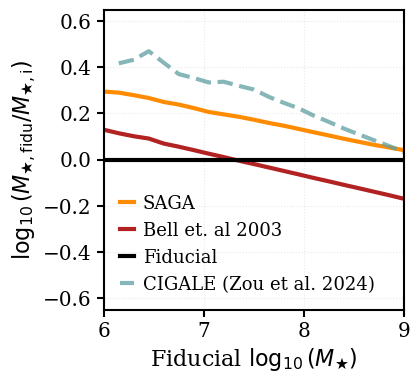

In [137]:
fig,ax = make_subplots(1,1,return_fig=True)


lw = 3

# bin_cens, mia_comp = get_median_relation(main["LOG_MSTAR_M24"].data, mstar_mia_NO_CORR)
# bin_cens, saga_nc_c10_comp = get_median_relation(main["LOG_MSTAR_M24"].data, mstar_saga_NO_CORR)

#######

bin_cens, mia_comp = get_median_relation(main["LOG_MSTAR_M24"].data, mstar_mia_YES_CORR)
bin_cens, saga_comp = get_median_relation(main["LOG_MSTAR_M24"].data, mstar_saga_NO_CORR)

bin_cens, bell03_comp = get_median_relation(main["LOG_MSTAR_M24"].data, mstar_bell03)

bin_cens, cigale_comp = get_median_relation(main_hu_match["LOG_MSTAR_M24"], np.log10(hu_match["MASS_CG"]) + 0.03)

#######c


ax[0].plot(bin_cens, saga_comp,lw=lw, label = r"SAGA",color="darkorange")

ax[0].plot(bin_cens, bell03_comp,lw=lw,color="firebrick", label = "Bell et. al 2003")

ax[0].plot(bin_cens, mia_comp,lw=lw,color="k", label = "Fiducial")

ax[0].plot(bin_cens, cigale_comp,lw=lw,label=r"CIGALE (Zou et al. 2024)",color="cadetblue",ls="--",alpha=0.75)


###

ax[0].legend(frameon=False, fontsize = 13,loc="lower left",handlelength=0.75,handletextpad=0.5)
ax[0].set_xlim([6,9])
ax[0].set_ylim([-0.65,0.65])

ax[0].set_xlabel(r"Fiducial $\log_{10}(M_{\bigstar})$",size= 16)
ax[0].set_ylabel(r"$\log_{10}(M_{\bigstar, \rm fidu} / M_{\bigstar, \rm i})$",size= 16)
ax[0].grid(ls = ":",color = "lightgrey",alpha = 0.5)
    
xgrid = np.linspace(6,9.25,100)
# make_alternating_plot(ax[0],xgrid,0*xgrid,dash_len=1,color_1="yellowgreen",color_2="k",lw=1)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stellar_mass_comp_wo_neb.pdf",bbox_inches="tight")

plt.show()

## Compare some of the dwarfs in our catalog with objects from Spitzer Local Volume sample!

In [17]:
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

# Read the fixed-width file using the byte positions from the readme
from astropy.io import ascii

col_starts = [0, 15, 18, 21, 27, 28, 31, 34, 39, 45, 48, 52, 57, 59, 66, 72, 74]
col_ends   = [13, 16, 19, 25, 27, 29, 32, 37, 43, 46, 50, 55, 57, 64, 70, 72, 78]
col_names  = ['Name', 'RAh', 'RAm', 'RAs', 'DE_sign', 'DEd', 'DEm', 'DEs',
              'Dist', 'TT', 'Ab_O', 'e_Ab_O', 'r_Ab_O', 'Meth', 'AFUV', 'r_AFUV', 'logMstar']

spitzer_lvl_cat = ascii.read(
    '/pscratch/sd/v/virajvm/catalog/spitzer_lvl_catalog.dat',
    format='fixed_width_no_header',
    col_starts=col_starts,
    col_ends=col_ends,
    names=col_names,
    fill_values=[('---', '')],
)

# Build coordinate strings and parse with SkyCoord
ra_strings = [f"{h} {m} {s}" for h, m, s in zip(spitzer_lvl_cat['RAh'], spitzer_lvl_cat['RAm'], spitzer_lvl_cat['RAs'])]
dec_strings = [f"{sign}{d} {m} {s}" for sign, d, m, s in zip(spitzer_lvl_cat['DE_sign'], spitzer_lvl_cat['DEd'], spitzer_lvl_cat['DEm'], spitzer_lvl_cat['DEs'])]

coords = SkyCoord(ra_strings, dec_strings, unit=(u.hourangle, u.deg))

# Add RA, Dec in degrees to the table
spitzer_lvl_cat['RA_deg'] = coords.ra.deg
spitzer_lvl_cat['Dec_deg'] = coords.dec.deg

vals = []
for x in spitzer_lvl_cat['logMstar']:
    try:
        vals.append(float(x))
    except (ValueError, TypeError):
        vals.append(99.0)
spitzer_lvl_cat['logMstar'] = vals

# Print the columns of interest
print(spitzer_lvl_cat['Name', 'RA_deg', 'Dec_deg', 'logMstar'][:4])

  Name        RA_deg             Dec_deg       logMstar
------- ------------------ ------------------- --------
    WLM 0.4923333333333333 -15.460916666666666     7.42
NGC0024  2.485583333333333  -24.96313888888889     9.37
NGC0045 3.5166249999999994 -23.182083333333335     9.55
NGC0055  3.723333333333333 -39.196638888888884     9.53


/tmp/ipykernel_1194756/1847091273.py:35: UserWarning: Warning: converting a masked element to nan.
  vals.append(float(x))


In [59]:
## let us cross match our dwarf catalog with spitzer to see how it looks!!

main_f = main_all[main_all["DWARF_MASKBIT"] == 0]

idx,d2d,_ = match_c_to_catalog(c_cat=main_f, catalog_cat=spitzer_lvl_cat,catalog_ra="RA_deg",catalog_dec="Dec_deg")


In [60]:
main_spitz_match = main_f[d2d.arcsec < main_f["R50_R"].data]
spitz_match = spitzer_lvl_cat[idx][d2d.arcsec < main_f["R50_R"].data]


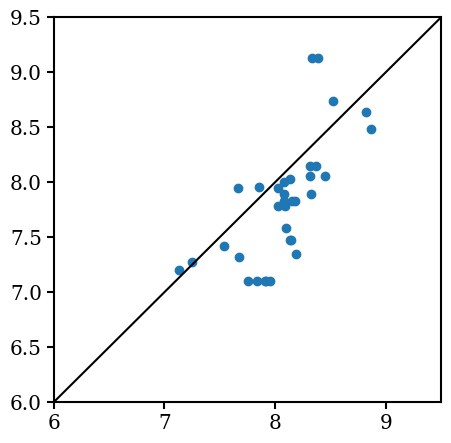

In [138]:
plt.figure(figsize = (5,5))
plt.scatter( main_spitz_match["LOG_MSTAR_M24"].data, spitz_match["logMstar"].data - 0.25)
plt.plot([6,9.5],[6,9.5],color="k")
plt.xlim([6,9.5])
plt.ylim([6,9.5])
plt.show()

In [139]:
print(np.median(main_spitz_match["LOG_MSTAR_M24"].data - spitz_match["logMstar"].data -0.25) )
print(np.std(main_spitz_match["LOG_MSTAR_M24"].data - spitz_match["logMstar"].data -0.25) )
print(np.percentile(main_spitz_match["LOG_MSTAR_M24"].data - spitz_match["logMstar"].data -0.25, 16) )
print(np.percentile(main_spitz_match["LOG_MSTAR_M24"].data - spitz_match["logMstar"].data-0.25, 84) )


-0.24838239669799833
0.3941612141712317
-0.555385961151123
0.17501750946044944


array([8.08166885, 8.18109035, 8.1510973 , 8.85808563, 7.67308903,
       8.86182785, 8.13859463, 7.75274181, 8.47943306, 8.34913921,
       8.02464294, 8.02994728, 8.31371212, 8.36823273, 6.39515638,
       8.82502937, 8.17428017, 7.90983438, 7.95587492, 7.75165033,
       7.83525896, 8.31156635, 8.02518368, 7.24990225, 7.66435099,
       8.38596821, 8.33046627, 8.42413902, 8.41551018, 8.81332302,
       7.13089085, 8.16812801, 7.85798597, 8.18828106, 8.321311  ,
       8.09920597, 7.5375123 , 8.1475153 , 8.08350086, 8.07596684,
       8.13310623, 8.45413589, 8.08727837, 7.91617012, 8.51897144,
       9.08607578, 9.23194027])

## We also make a plot of scatter in the mstar estimates as a function of redshift from the associated fibers

In [7]:
main_all[:2]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int64,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,bytes10,int64
39627066986994125,sv1,bright,34722,0.032918604316881296,98.85089745232835,False,0.03264401958193863,58.82791003142589,-31.167992883134954,58.82791003142589,-31.167992883134954,DESI J058.8279-31.1679,148.21792602539062,8.843826293945312,0.04251172982109555,18.319110870361328,17.939651489257812,17.730533599853516,18.319110870361328,17.939651489257812,17.730533599853516,BGS_BRIGHT,0,0,TRACTOR_OG,False,7.116967678070068,0.6592394709587097 .. -87.19556427001953,False,[39627066986994125],39627066986994125,True,V_CMB,39627066986994125
39627066995376721,sv1,bright,34721,0.06713081686670527,444.1444324851036,False,0.06685584372174991,59.235244922847556,-31.360982247692228,59.235244922847556,-31.360982247692228,DESI J059.2352-31.3609,311.04266357421875,9.242656707763672,0.02500834480091534,19.275266647338867,18.767732620239258,18.4816951751709,19.275266647338867,18.767732620239258,18.4816951751709,BGS_BRIGHT,0,0,TRACTOR_OG,False,1.832580804824829,0.9732345342636108 .. -16.84249496459961,False,[39627066995376721],39627066995376721,True,V_CMB,39627066995376721


In [14]:
fib_based_all[:2]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,int32,bytes13,bool,float64,float64[2],bool,int64,bool,bytes10
39627066986994125,sv1,bright,34722,0.032918604316881296,98.85089745232835,False,0.03264401958193863,58.82791003142589,-31.167992883134954,58.82791003142589,-31.167992883134954,DESI J058.8279-31.1679,148.21792602539062,8.843826293945312,0.04251172982109555,18.319110870361328,17.939651489257812,17.730533599853516,18.319110870361328,17.939651489257812,17.730533599853516,BGS_BRIGHT,0,0,TRACTOR_OG,False,7.116967678070068,0.6592394709587097 .. -87.19556427001953,False,39627066986994125,True,V_CMB
39627066995376721,sv1,bright,34721,0.06713081686670527,444.1444324851036,False,0.06685584372174991,59.235244922847556,-31.360982247692228,59.235244922847556,-31.360982247692228,DESI J059.2352-31.3609,311.04266357421875,9.242656707763672,0.02500834480091534,19.275266647338867,18.767732620239258,18.4816951751709,19.275266647338867,18.767732620239258,18.4816951751709,BGS_BRIGHT,0,0,TRACTOR_OG,False,1.832580804824829,0.9732345342636108 .. -16.84249496459961,False,39627066995376721,True,V_CMB


In [93]:
zreds = []
mstar_diffs = []
tgids = []

main_prim = main_all[(main_all["DWARF_PRIMARY"] == 1) & (main_all["DWARF_MASKBIT"] == 0)]

#main_assoc is the entire catalog!!
main_assoc = fib_based_all[ (fib_based_all["DWARF_MASKBIT"] == 0) ]

#looping over the primary targetids we know
for i in trange(len(main_prim)):

    prop_tgid = main_prim["PROPERTY_SOURCE_TARGETID"][i]

    #we only consider objects that have mroe than 1 associated targetids
    if len(main_prim["ASSOCIATED_TARGETIDS"][i]) <= 1:
        pass
    else:
        #we have multiple fibers and we will look at their stellar masses
        #from all targetids we know, which ones appear in teh associted one for this galaxy
        #ahh but er need to remove the target that is already primary to avoud comparing with itself!!
        
        assoc_ids = main_prim["ASSOCIATED_TARGETIDS"][i]
        assoc_ids_no_self = assoc_ids[assoc_ids != prop_tgid]
        tgid_mask_i = np.isin(main_assoc["TARGETID"].data, assoc_ids_no_self)

        if np.sum(tgid_mask_i) == 0:
            pass
        else:
            main_assoc_i =  main_assoc[tgid_mask_i]

            main_assoc_i = main_assoc_i[main_assoc_i["MAG_TYPE"] != "TRACTOR_OG"]

            if len(main_assoc_i) == 0:
                pass
            else:
    
                #read in the mstars from that!!
                mstar_vals = main_assoc_i["LOG_MSTAR_M24"].data
        
                zreds.append( len(mstar_vals) * [ float(main_prim["Z"][i]) ] )
                mstar_diffs.append( mstar_vals - main_prim["LOG_MSTAR_M24"][i] )
                tgids.append( len(mstar_vals) * [main_prim["TARGETID"][i]] )
    

100%|██████████| 413788/413788 [00:16<00:00, 25713.90it/s] 


In [94]:
##ARE THERE DWARF PRIMARIES THAT EXIST IN MULTIPLE DWARFS?
zreds_con = np.concatenate(zreds)
delt_mstar_con = np.concatenate(mstar_diffs)
tgid_con = np.concatenate(tgids)


In [95]:
fib_based_all[:2]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,int32,bytes13,bool,float64,float64[2],bool,int64,bool,bytes10
39627066986994125,sv1,bright,34722,0.032918604316881296,98.85089745232835,False,0.03264401958193863,58.82791003142589,-31.167992883134954,58.82791003142589,-31.167992883134954,DESI J058.8279-31.1679,148.21792602539062,8.843826293945312,0.04251172982109555,18.319110870361328,17.939651489257812,17.730533599853516,18.319110870361328,17.939651489257812,17.730533599853516,BGS_BRIGHT,0,0,TRACTOR_OG,False,7.116967678070068,0.6592394709587097 .. -87.19556427001953,False,39627066986994125,True,V_CMB
39627066995376721,sv1,bright,34721,0.06713081686670527,444.1444324851036,False,0.06685584372174991,59.235244922847556,-31.360982247692228,59.235244922847556,-31.360982247692228,DESI J059.2352-31.3609,311.04266357421875,9.242656707763672,0.02500834480091534,19.275266647338867,18.767732620239258,18.4816951751709,19.275266647338867,18.767732620239258,18.4816951751709,BGS_BRIGHT,0,0,TRACTOR_OG,False,1.832580804824829,0.9732345342636108 .. -16.84249496459961,False,39627066995376721,True,V_CMB


In [96]:
from desi_lowz_funcs import get_contours

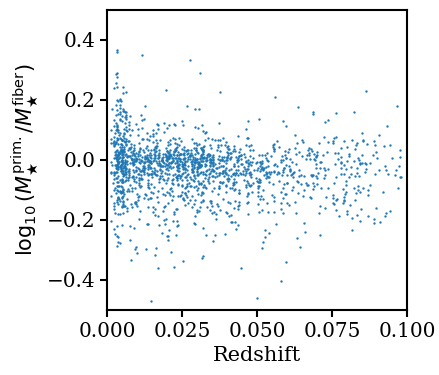

In [98]:
fig,ax = make_subplots(1,1,return_fig=True)
ax[0].scatter( zreds_con, delt_mstar_con,s=0.5 )
# ax[0].hist2d( zreds_con, delt_mstar_con,range=( (0,0.1), (-0.5,0.5)),bins=40,norm=LogNorm() )


conts_dict = get_contours( zreds_con, delt_mstar_con, bins=np.arange(0,0.1,0.0075),sigs=True )

# ax[0].plot(conts_dict["bin_cents"], conts_dict["median"],color="k")
# ax[0].fill_between(conts_dict["bin_cents"], y1= conts_dict["sig1_low"],y2 = conts_dict["sig1_high"], color="k",alpha=0.5)
# ax[0].fill_between(conts_dict["bin_cents"], y1= conts_dict["sig2_low"],y2 = conts_dict["sig2_high"], color="k",alpha=0.25)

ax[0].set_xlim([0,0.1])
ax[0].set_ylim([-0.5,0.5])
ax[0].set_xlabel("Redshift",fontsize=15)
ax[0].set_ylabel(r"$\log_{10} (M_{\bigstar}^{\rm prim.} / M_{\bigstar}^{\rm fiber})$",fontsize=15)

# import numpy as np
# from scipy.stats import binned_statistic

# zbins = np.linspace(0, 0.1, 25)
# zmid = 0.5 * (zbins[:-1] + zbins[1:])

# median = binned_statistic(zreds_con, delt_mstar_con, statistic='median', bins=zbins).statistic
# p16 = binned_statistic(zreds_con, delt_mstar_con, statistic=lambda x: np.percentile(x, 16), bins=zbins).statistic
# p84 = binned_statistic(zreds_con, delt_mstar_con, statistic=lambda x: np.percentile(x, 84), bins=zbins).statistic

# ax[0].fill_between(zmid, p16, p84, alpha=0.3)
# ax[0].plot(zmid, median, color='k', lw=2)

plt.show()


In [99]:
## even still some objects are left!!

In [66]:
np.percentile(delt_mstar_con[zreds_con < 0.075], 16), np.percentile(delt_mstar_con[zreds_con < 0.075], 84)

(-0.11171730041503906, 0.03407546997070311)

In [ ]:
## sometimes some of the large diffrences are because objects are overmerged --- 

In [33]:
tgid_con[ np.abs(delt_mstar_con) > 0.4]

#some of the large differences are because of shreds being correctly handled now!
#can make a note of this pin the aper.


array([39627636917406276, 39627637575914610, 39627691632105012,
       39627709264959206, 39627716063924391, 39627746346798358,
       39627751476433103, 39627756874503026, 39627776554175302,
       39627787182540222, 39627806656693663, 39627847958006497,
       39628005479285555, 39628251659770512, 39628374716452088,
       39628384581455385, 39628439719773430, 39632930158413026,
       39633203748668189, 39627975729092420,  2715147344805889,
       39627679653170542, 39627684560504842, 39627690721935618,
       39627726520323672, 39627727766033160, 39627814504244760,
       39627660875268660, 39627666323671508, 39627751577095177,
       39627751577095177, 39627773790128095, 39627790219220294,
       39627849207911774, 39627878198938674, 39627896603545910,
       39627975431295554, 39627992825069945, 39628112417261210,
       39628125507686730, 39628502567229604, 39633026019230301,
       39633130436429340, 39633325530285940, 39633145640784829,
       39627750897615084, 39627836272678

In [40]:
# main_all[main_all["TARGETID"] == 39627709264959315 ]

In [216]:
np.sum(fastspec_all["SNR_R"] < 0.5)

64696

In [219]:
np.sum(fastspec_all["SNR_B"] > 0.5)

324814

In [228]:
1.0857/10

0.10857000000000001

In [ ]:
## if 

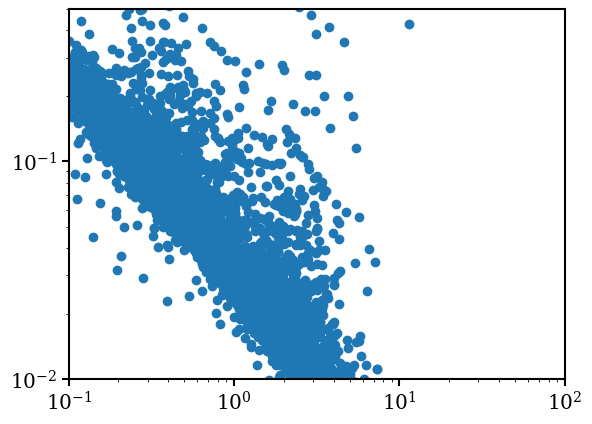

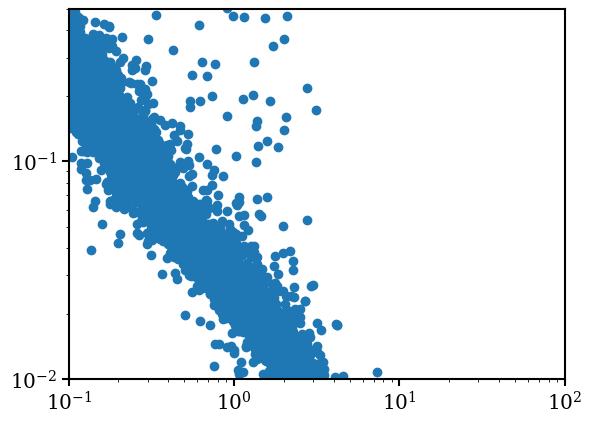

In [229]:
plt.scatter( fastspec_all["SNR_R"], fastspec_all["MAG_R_FIBER_NOEMI_ERR"] )
plt.ylim([1e-2,0.5])
plt.xlim([0.1,100])
plt.xscale("log")
plt.yscale("log")

plt.show()

plt.scatter( fastspec_all["SNR_B"], fastspec_all["MAG_G_FIBER_NOEMI_ERR"] )
plt.ylim([1e-2,0.5])
plt.xlim([0.1,100])
plt.xscale("log")
plt.yscale("log")

plt.show()

In [204]:
fastspec_all[fastspec_all["TARGETID"] == 39627468348330752]

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,LOGMSTAR,MAG_G_FIBER_NOEMI,MAG_R_FIBER_NOEMI,MAG_G_FIBER_NOEMI_ERR,MAG_R_FIBER_NOEMI_ERR,MAG_G_DECAM_MODEL_NOEMI,MAG_R_DECAM_MODEL_NOEMI,MAG_G_DECAM_MODEL_WEMI,MAG_R_DECAM_MODEL_WEMI,MAG_G_BASS_MODEL_WEMI,MAG_R_BASS_MODEL_WEMI,MAG_G_SDSS_MODEL_NOEMI,MAG_R_SDSS_MODEL_NOEMI,MAG_G_SDSS_Z0_MODEL_NOEMI,MAG_R_SDSS_Z0_MODEL_NOEMI,DELTA_MAG_G_BASS2DECAM,DELTA_MAG_R_BASS2DECAM,DELTA_MAG_G_NEB,DELTA_MAG_R_NEB,DELTA_MAG_G_DECAM2SDSS,DELTA_MAG_R_DECAM2SDSS,DELTA_MAG_G_KCORR,DELTA_MAG_R_KCORR
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627468348330752,66.12262228976239,-13.175702892461622,0.36956775,0.16289926,0.18058643,25.695404,23.445698,25.695404,33.727856,29.943033,0.05905413,44.37011,0.03902064,0.0,0.0,0.17354126,0.17864221,26.187746,0.21379162,23.212957,0.22058584,67.98495,0.2143082,3.2420661,0.61414105,1.8858305,0.92588806,76.00328,0.64973724,0.0,0.0,5.582039,1.2258369,9.954164,1.0156076,6.303719,1.442263,5.094642,2.2895126,0.0,0.0,76.86141,0.30608588,359.54922,1.6588603e-05,0.7193408,0.66758144,17.199015,1.0624459,125.0,0.0,7.540031,22.51974314274923,23.534502379807893,0.08029420355097289,0.195317626741217,22.375921138665152,24.329588818808435,22.167901890909643,23.277731252712016,22.156914246711143,23.294281720532638,22.286650607342068,23.610880578686544,22.43173025010501,24.71790768523777,0.0,-0.0,0.20801924775550873,1.0518575660964196,-0.08927053132308416,-0.7187082401218916,0.1450796427629406,1.1070271065512252


In [181]:
## THIS IS WRONG ABOVE, WHY DO THEY DISAGREE!!!

print( get_stellar_mass_mia( [ 17.27 - 16.92], [17.27], [0.03], [137.237], input_zred=False ) )

print( get_stellar_mass_mia( [ 17.434 - 17.035], [17.434], [0.03], [137.449], input_zred=False ) )



[9.17495027]
[9.18293303]


In [182]:
temp = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_BRIGHT_shreds_catalog_w_aper_mags.fits")


In [184]:
temp[temp["TARGETID"] == 39627468348330752 ]

TARGETID,SURVEY,PROGRAM,HEALPIX,SPGRPVAL,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,COADD_FIBERSTATUS,RA,DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FIBERFLUX_R,MASKBITS,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD,TSNR2_GPBDARK_B,TSNR2_ELG_B,TSNR2_GPBBRIGHT_B,TSNR2_LYA_B,TSNR2_BGS_B,TSNR2_GPBBACKUP_B,TSNR2_QSO_B,TSNR2_LRG_B,TSNR2_GPBDARK_R,TSNR2_ELG_R,TSNR2_GPBBRIGHT_R,TSNR2_LYA_R,TSNR2_BGS_R,TSNR2_GPBBACKUP_R,TSNR2_QSO_R,TSNR2_LRG_R,TSNR2_GPBDARK_Z,TSNR2_ELG_Z,TSNR2_GPBBRIGHT_Z,TSNR2_LYA_Z,TSNR2_BGS_Z,TSNR2_GPBBACKUP_Z,TSNR2_QSO_Z,TSNR2_LRG_Z,TSNR2_GPBDARK,TSNR2_ELG,TSNR2_GPBBRIGHT,TSNR2_LYA,TSNR2_BGS,TSNR2_GPBBACKUP,TSNR2_QSO,TSNR2_LRG,MAIN_NSPEC,MAIN_PRIMARY,SV_NSPEC,SV_PRIMARY,ZCAT_NSPEC,ZCAT_PRIMARY,DESINAME,FLUX_G,FLUX_IVAR_G,MAG_G,MAG_G_ERR,FLUX_R,FLUX_IVAR_R,MAG_R,MAG_R_ERR,FLUX_Z,FLUX_IVAR_Z,MAG_Z,MAG_Z_ERR,FIBERMAG_R,OBJID,SIGMA_G,FRACFLUX_G,RCHISQ_G,SIGMA_GOOD_G,SIGMA_R,FRACFLUX_R,RCHISQ_R,SIGMA_GOOD_R,SIGMA_Z,FRACFLUX_Z,RCHISQ_Z,SIGMA_GOOD_Z,SHAPE_R,SHAPE_R_ERR,MU_R,MU_R_ERR,SERSIC,SERSIC_IVAR,BA,TYPE,PHI,NOBS_G,NOBS_R,NOBS_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,V_HELIO,V_GSR,V_CMB,Z_CMB,DIST_MPC_VCMB,DIST_MPC_FIDU,DIST_MPC_NAM,OTHER_DIST_MPC_NAM,LOGM_SAGA_VCMB,LOGM_SAGA_FIDU,LOGM_M24_VCMB,SWEEP,is_south,STARFDIST,STARDIST_DEG,STARMAG,STAR_RADIUS_ARCSEC,STAR_RA,STAR_DEC,GOOD_SIGMA,PHOTO_REPROCESS,IMAGE_SIZE_PIX,SAMPLE,SGA_ID_MATCH,SGA_D26_NORM_DIST,SGA_DIST_DEG,PCNN_FRAGMENT,IMAGE_PATH,FILE_PATH,NEAREST_STAR_NORM_DIST,NEAREST_STAR_MAX_MAG,APER_ORG_R3_MAG,APER_ORG_R3_NO_SUBTRACT_MAG,SAVE_PATH,APER_SOURCE_ON_ORG_BLOB,SAVE_SUMMARY_APER_PATH,APER_ORG_R3_FRAC_MASK_PIX,IMAGE_MASK_PIX_FRAC,COG_MAG_G_ISOLATE,COG_MAG_R_ISOLATE,COG_MAG_Z_ISOLATE,COG_MAG_G_NO_ISOLATE,COG_MAG_R_NO_ISOLATE,COG_MAG_Z_NO_ISOLATE,APER_R4_MAG_G_ISOLATE,APER_R4_MAG_R_ISOLATE,APER_R4_MAG_Z_ISOLATE,APER_R4_MAG_G_NO_ISOLATE,APER_R4_MAG_R_NO_ISOLATE,APER_R4_MAG_Z_NO_ISOLATE,TRACTOR_ONLY_MAG_G_ISOLATE,TRACTOR_ONLY_MAG_R_ISOLATE,TRACTOR_ONLY_MAG_Z_ISOLATE,TRACTOR_ONLY_MAG_G_NO_ISOLATE,TRACTOR_ONLY_MAG_R_NO_ISOLATE,TRACTOR_ONLY_MAG_Z_NO_ISOLATE,TRACTOR_BRIGHTEST_SOURCE_MAGS_ISOLATE,TRACTOR_BRIGHTEST_SOURCE_MAGS_NO_ISOLATE,SIMPLE_PHOTO_MAG_G,SIMPLE_PHOTO_MAG_R,SIMPLE_PHOTO_MAG_Z,COG_MAG_ERR_ISOLATE,FIBER_MAG_ISOLATE,COG_PARAMS_G_ISOLATE,COG_PARAMS_R_ISOLATE,COG_PARAMS_Z_ISOLATE,COG_PARAMS_G_ERR_ISOLATE,COG_PARAMS_R_ERR_ISOLATE,COG_PARAMS_Z_ERR_ISOLATE,APERFRAC_R4_IN_IMG_ISOLATE,COG_CHI2_ISOLATE,COG_DOF_ISOLATE,COG_DECREASE_MAX_LEN_ISOLATE,COG_DECREASE_MAX_MAG_ISOLATE,APER_PARAMS_ISOLATE,APER_CEN_RADEC_ISOLATE,APER_CEN_XY_PIX_ISOLATE,APER_R4_MASK_FRAC_ISOLATE,APER_CEN_MASKED_ISOLATE,APER_MU_R_SIZES_ISOLATE,COG_MAG_ERR_NO_ISOLATE,FIBER_MAG_NO_ISOLATE,COG_PARAMS_G_NO_ISOLATE,COG_PARAMS_R_NO_ISOLATE,COG_PARAMS_Z_NO_ISOLATE,COG_PARAMS_G_ERR_NO_ISOLATE,COG_PARAMS_R_ERR_NO_ISOLATE,COG_PARAMS_Z_ERR_NO_ISOLATE,APERFRAC_R4_IN_IMG_NO_ISOLATE,COG_CHI2_NO_ISOLATE,COG_DOF_NO_ISOLATE,COG_DECREASE_MAX_LEN_NO_ISOLATE,COG_DECREASE_MAX_MAG_NO_ISOLATE,APER_PARAMS_NO_ISOLATE,APER_CEN_RADEC_NO_ISOLATE,APER_CEN_XY_PIX_NO_ISOLATE,APER_R4_MASK_FRAC_NO_ISOLATE,APER_CEN_MASKED_NO_ISOLATE,APER_MU_R_SIZES_NO_ISOLATE,TRACTOR_ONLY_COG_MAG_ISOLATE,TRACTOR_ONLY_FIBER_MAG_ISOLATE,TRACTOR_ONLY_COG_MAG_ERR_ISOLATE,TRACTOR_ONLY_COG_PARAMS_G_ISOLATE,TRACTOR_ONLY_COG_PARAMS_G_ERR_ISOLATE,TRACTOR_ONLY_COG_PARAMS_R_ISOLATE,TRACTOR

In [196]:
from consolidate_photometry import consolidate_new_photo, consolidate_positions_and_shapes
from mass_and_photo_corrections import _apply_delta_mag_corrections

bgsb_shred = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_BRIGHT_shreds_catalog_w_aper_mags.fits")
bgsb_shred = consolidate_new_photo(bgsb_shred,sample="BGS_BRIGHT",flag_cog_nan_always=True)

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.24410323753724936
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.062276
MASKBIT=2^2, bad resid, fraction : 0.0058
MASKBIT=2^3, cog curve decrease, fraction: 0.0101
MASKBIT=2^4, aperfrac-in image, fraction: 0.001111
MASKBIT=2^5, aperfrac-mask image, fraction: 0.050659
MASKBIT=2^6, image-frac mask, fraction: 0.000859
MASKBIT=2^7, bad colors, fraction: 0.000303
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.106420
MASKBIT=2^10, aper-cen masked, fraction: 0.052174
MASKBIT=2^11, no seg found, fraction: 0.000051
MASKBIT=2^12, near sga outskirts, fraction: 0.014597
Fraction of sources where org trac is likely good = 0.24410323753724936
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect som

In [197]:
bgsb_shred[bgsb_shred["TARGETID"] == 39627468348330752 ]

TARGETID,SURVEY,PROGRAM,HEALPIX,SPGRPVAL,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,COADD_FIBERSTATUS,RA,DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FIBERFLUX_R,MASKBITS,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD,TSNR2_GPBDARK_B,TSNR2_ELG_B,TSNR2_GPBBRIGHT_B,TSNR2_LYA_B,TSNR2_BGS_B,TSNR2_GPBBACKUP_B,TSNR2_QSO_B,TSNR2_LRG_B,TSNR2_GPBDARK_R,TSNR2_ELG_R,TSNR2_GPBBRIGHT_R,TSNR2_LYA_R,TSNR2_BGS_R,TSNR2_GPBBACKUP_R,TSNR2_QSO_R,TSNR2_LRG_R,TSNR2_GPBDARK_Z,TSNR2_ELG_Z,TSNR2_GPBBRIGHT_Z,TSNR2_LYA_Z,TSNR2_BGS_Z,TSNR2_GPBBACKUP_Z,TSNR2_QSO_Z,TSNR2_LRG_Z,TSNR2_GPBDARK,TSNR2_ELG,TSNR2_GPBBRIGHT,TSNR2_LYA,TSNR2_BGS,TSNR2_GPBBACKUP,TSNR2_QSO,TSNR2_LRG,MAIN_NSPEC,MAIN_PRIMARY,SV_NSPEC,SV_PRIMARY,ZCAT_NSPEC,ZCAT_PRIMARY,DESINAME,FLUX_G,FLUX_IVAR_G,MAG_G,MAG_G_ERR,FLUX_R,FLUX_IVAR_R,MAG_R,MAG_R_ERR,FLUX_Z,FLUX_IVAR_Z,MAG_Z,MAG_Z_ERR,FIBERMAG_R,OBJID,SIGMA_G,FRACFLUX_G,RCHISQ_G,SIGMA_GOOD_G,SIGMA_R,FRACFLUX_R,RCHISQ_R,SIGMA_GOOD_R,SIGMA_Z,FRACFLUX_Z,RCHISQ_Z,SIGMA_GOOD_Z,SHAPE_R,SHAPE_R_ERR,MU_R,MU_R_ERR,SERSIC,SERSIC_IVAR,BA,TYPE,PHI,NOBS_G,NOBS_R,NOBS_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,V_HELIO,V_GSR,V_CMB,Z_CMB,DIST_MPC_VCMB,DIST_MPC_FIDU,DIST_MPC_NAM,OTHER_DIST_MPC_NAM,LOGM_SAGA_VCMB,LOGM_SAGA_FIDU,LOGM_M24_VCMB,SWEEP,is_south,STARFDIST,STARDIST_DEG,STARMAG,STAR_RADIUS_ARCSEC,STAR_RA,STAR_DEC,GOOD_SIGMA,PHOTO_REPROCESS,IMAGE_SIZE_PIX,SAMPLE,PCNN_FRAGMENT,IMAGE_PATH,FILE_PATH,NEAREST_STAR_NORM_DIST,NEAREST_STAR_MAX_MAG,APER_ORG_R3_MAG,APER_ORG_R3_NO_SUBTRACT_MAG,SAVE_PATH,APER_SOURCE_ON_ORG_BLOB,SAVE_SUMMARY_APER_PATH,APER_ORG_R3_FRAC_MASK_PIX,IMAGE_MASK_PIX_FRAC,COG_MAG_G_ISOLATE,COG_MAG_R_ISOLATE,COG_MAG_Z_ISOLATE,COG_MAG_G_NO_ISOLATE,COG_MAG_R_NO_ISOLATE,COG_MAG_Z_NO_ISOLATE,APER_R4_MAG_G_ISOLATE,APER_R4_MAG_R_ISOLATE,APER_R4_MAG_Z_ISOLATE,APER_R4_MAG_G_NO_ISOLATE,APER_R4_MAG_R_NO_ISOLATE,APER_R4_MAG_Z_NO_ISOLATE,TRACTOR_ONLY_MAG_G_ISOLATE,TRACTOR_ONLY_MAG_R_ISOLATE,TRACTOR_ONLY_MAG_Z_ISOLATE,TRACTOR_ONLY_MAG_G_NO_ISOLATE,TRACTOR_ONLY_MAG_R_NO_ISOLATE,TRACTOR_ONLY_MAG_Z_NO_ISOLATE,TRACTOR_BRIGHTEST_SOURCE_MAGS_ISOLATE,TRACTOR_BRIGHTEST_SOURCE_MAGS_NO_ISOLATE,SIMPLE_PHOTO_MAG_G,SIMPLE_PHOTO_MAG_R,SIMPLE_PHOTO_MAG_Z,COG_MAG_ERR_ISOLATE,FIBER_MAG_ISOLATE,COG_PARAMS_G_ISOLATE,COG_PARAMS_R_ISOLATE,COG_PARAMS_Z_ISOLATE,COG_PARAMS_G_ERR_ISOLATE,COG_PARAMS_R_ERR_ISOLATE,COG_PARAMS_Z_ERR_ISOLATE,APERFRAC_R4_IN_IMG_ISOLATE,COG_CHI2_ISOLATE,COG_DOF_ISOLATE,COG_DECREASE_MAX_LEN_ISOLATE,COG_DECREASE_MAX_MAG_ISOLATE,APER_PARAMS_ISOLATE,APER_CEN_RADEC_ISOLATE,APER_CEN_XY_PIX_ISOLATE,APER_R4_MASK_FRAC_ISOLATE,APER_CEN_MASKED_ISOLATE,APER_MU_R_SIZES_ISOLATE,COG_MAG_ERR_NO_ISOLATE,FIBER_MAG_NO_ISOLATE,COG_PARAMS_G_NO_ISOLATE,COG_PARAMS_R_NO_ISOLATE,COG_PARAMS_Z_NO_ISOLATE,COG_PARAMS_G_ERR_NO_ISOLATE,COG_PARAMS_R_ERR_NO_ISOLATE,COG_PARAMS_Z_ERR_NO_ISOLATE,APERFRAC_R4_IN_IMG_NO_ISOLATE,COG_CHI2_NO_ISOLATE,COG_DOF_NO_ISOLATE,COG_DECREASE_MAX_LEN_NO_ISOLATE,COG_DECREASE_MAX_MAG_NO_ISOLATE,APER_PARAMS_NO_ISOLATE,APER_CEN_RADEC_NO_ISOLATE,APER_CEN_XY_PIX_NO_ISOLATE,APER_R4_MASK_FRAC_NO_ISOLATE,APER_CEN_MASKED_NO_ISOLATE,APER_MU_R_SIZES_NO_ISOLATE,TRACTOR_ONLY_COG_MAG_ISOLATE,TRACTOR_ONLY_FIBER_MAG_ISOLATE,TRACTOR_ONLY_COG_MAG_ERR_ISOLATE,TRACTOR_ONLY_COG_PARAMS_G_ISOLATE,TRACTOR_ONLY_COG_PARAMS_G_ERR_ISOLATE,TRACTOR_ONLY_COG_PARAMS_R_ISOLATE,TRACTOR_ONLY_COG_PARAMS_R_ERR_ISOLATE,TRACTOR_ONLY_

In [198]:
from consolidate_photometry import create_main_data_model

tot_shred, tot_shred_entire = create_main_data_model(bgsb_shred, "temp.fits", clean_cat=False)

Processing shred catalog!
Adding the consolidated RA,DEC, and SHAPE columns


100%|██████████| 19799/19799 [00:00<00:00, 187985.62it/s]


Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column
  Loaded DELTA_MAG + is_south from 48130 rows in iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 193585 rows in iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 66912 rows in iron_bgs_faint_filter_zsucc_zrr03_allfracflux_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 187920 rows in iron_elg_filter_zsucc_zrr05_allfracflux_INT_V2_NEBCORR.fits
  Combined NEBCORR DELTA_MAG table: 496035 unique TARGETIDs
_apply_delta_mag_corrections: matched 19799/19799 TARGETIDs to NEBCORR table
  Sanity check: max |TARGETID_catalog - TARGETID_nebcorr| = 0
Applying the dwarf galaxy cut!
Number before dwarf mass cut = 19799
Number after dwarf mass cut = 14581
  Loaded DELTA_MAG + is_south from 48130 rows in iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 193585 rows in iron_bgs_bright_filter_

In [199]:
tot_shred[tot_shred["TARGETID"] == 39627468348330752 ]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020
int64,str7,str6,int32,float64,float64,int8,float64,float64,float64,float64,float64,str22,float64,float64,float64,float64,float64,float64,float64,float64,str10,int32,str13,bool,float64,float64[2],bool
39627468348330752,main,bright,22584,0.030494591441658576,2738.5758627802134,0,0.030278008133970413,66.12085204106384,-13.1762029182984,66.12262228976239,-13.175702892461622,DESI J066.1226-13.1757,137.23745727539062,7.524060249328613,17.270193099975586,16.921152114868164,16.65509796142578,19.434215545654297,19.23270034790039,19.084306716918945,BGS_BRIGHT,0,COG,True,5.289618015289307,0.7756311893463135 .. 144.6537628173828,False


In [200]:
bgsb_shred["MAG_G"] = bgsb_shred["MAG_G_BEST"].copy()
bgsb_shred["MAG_R"] = bgsb_shred["MAG_R_BEST"].copy()
bgsb_shred["MAG_Z"] = bgsb_shred["MAG_Z_BEST"].copy()

bgsb_shred = consolidate_positions_and_shapes(bgsb_shred)

bgsb_shred.rename_column("PHOTO_MASKBIT", "DWARF_MASKBIT")

# Apply DELTA_MAG corrections (nebular + filter + k) to the
# reprocessed photometry, then compute stellar mass with zred=0
# (model k-correction already folded into the deltas).
mag_g_corr, mag_r_corr = _apply_delta_mag_corrections(bgsb_shred)

Adding the consolidated RA,DEC, and SHAPE columns


100%|██████████| 19799/19799 [00:00<00:00, 282570.76it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column


  Loaded DELTA_MAG + is_south from 48130 rows in iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 193585 rows in iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 66912 rows in iron_bgs_faint_filter_zsucc_zrr03_allfracflux_INT_V2_NEBCORR.fits
  Loaded DELTA_MAG + is_south from 187920 rows in iron_elg_filter_zsucc_zrr05_allfracflux_INT_V2_NEBCORR.fits
  Combined NEBCORR DELTA_MAG table: 496035 unique TARGETIDs
_apply_delta_mag_corrections: matched 19799/19799 TARGETIDs to NEBCORR table
  Sanity check: max |TARGETID_catalog - TARGETID_nebcorr| = 0


In [203]:
print(mag_g_corr[bgsb_shred["TARGETID"] == 39627468348330752  ])
print(mag_r_corr[bgsb_shred["TARGETID"] == 39627468348330752  ])

[17.53402143]
[18.36132908]


In [203]:
## how much does the luminosity distance differ between these different cosmologies over our redshift range of interest?

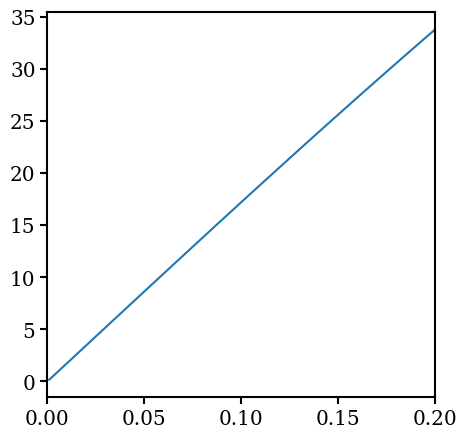

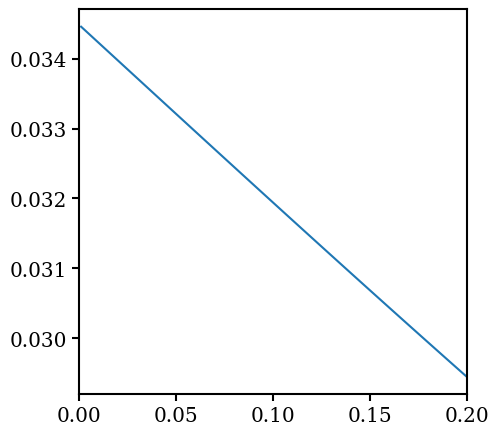

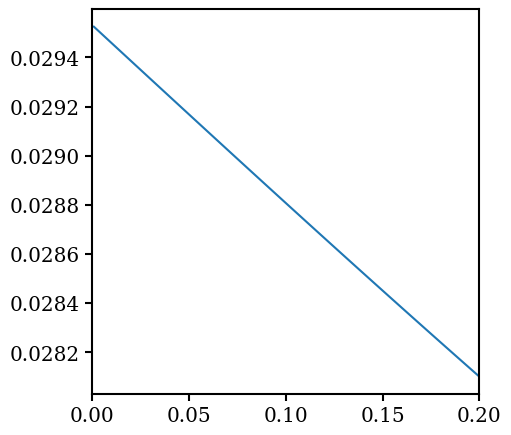

In [276]:
from astropy.cosmology import Planck18, WMAP7, FlatLambdaCDM

cosmos_flat = FlatLambdaCDM(H0=70, Om0=0.3)

zred_bins = np.linspace(0.001, 0.2,100)

p18_DLs = Planck18.luminosity_distance(zred_bins).value
w7_DLs = WMAP7.luminosity_distance(zred_bins).value
flat_DLs = cosmos_flat.luminosity_distance(zred_bins).value

# their cosmology (example)
plt.figure(figsize = (5,5))
plt.plot(zred_bins, p18_DLs -  w7_DLs)
plt.xlim([0,0.2])
plt.show()

##how much does this translate to an offset in absolute magnitudes
plt.figure(figsize = (5,5))
plt.plot(zred_bins, 0.4 * 5 * np.log10(p18_DLs / w7_DLs  ) )
plt.xlim([0,0.2])
plt.show()

plt.figure(figsize = (5,5))
plt.plot(zred_bins, 0.4 * 5 * np.log10(p18_DLs / flat_DLs  ) )
plt.xlim([0,0.2])
plt.show()




In [96]:
### ahhh how does the updated stellar mass relation from Mia de los reyes compare to the old one I was using!!

In [127]:
from desi_lowz_funcs import get_stellar_mass_mia

main = main[main["DWARF_MASKBIT"] == 0]

gr_color = main["MAG_G"].data - main["MAG_R"].data

g_mag = main["MAG_G"].data
d_in_mpc = main["LUMI_DIST_MPC"].data
zreds = main["Z_CMB"].data

from desi_lowz_funcs import g_kcorr

d_in_pc = d_in_mpc * 1e6
kg = g_kcorr(gr_color,zreds)

Mg = g_mag + 5 - 5*np.log10(d_in_pc) - kg


In [128]:
log_mstar_OLD = (1.433 * gr_color) + 0.00153 * (Mg**2) - (0.335 * Mg) + 2.072

log_mstar_NEW = get_stellar_mass_mia(gr_color, g_mag, zreds, d_in_mpc=d_in_mpc, input_zred=False)

In [129]:
len(log_mstar_NEW[log_mstar_NEW < 9.25])

212708

In [131]:
len(log_mstar_NEW)

218926

In [132]:
212708/218926

0.9715977088148506